# SIM 3000s — Shear localization analysis

Simulations 3000–3009 use the `A1000` mesh at ten aligned internal-pressure levels:
`P = [0.0] + [0.04 * sqrt(2)^i for i in 0..8]`.

The family uses a neo-Hookean material and an implicit dynamic quasi-static Step-1
(`*Dynamic, application=QUASI-STATIC, initial=NO`) with density scaling `1e-6`, a
-5 mm compression ramp, and `E = 20`. Compared with the 1000s family, both the
constitutive model and Step-1 solver differ; this is therefore a model-family analysis,
not a solver-only comparison.

This notebook mirrors `SIM_3010s_shear_localization.ipynb` and provides the same 17
localization, deformation, skeleton-pressure, and percolation analyses. It resolves
results through `I001_Results/AAA_fwd`, skips simulations whose reduced PKLs are not yet
available, and builds the family-specific caches incrementally:

- `shear_std_cache_3000s.pkl`
- `J_distortion_cache_3000s.pkl`
- `p_cache_3000s.pkl`
- `bar_fraction_cache_3000s.pkl`
- `cluster_diagnostics_3000s.pkl`
- `random_percolation_null_3000s.pkl`

The cache builders for full `TP2`, `B`, and `I2_3002` files are intentionally expensive;
missing source files are reported and skipped. The 3000s reduction is currently
incomplete, so re-run the notebook as reduced files become available.

**Plots**

1. Shear mean and standard deviation vs displacement
2. Their displacement derivatives
3. Mean J and distortional shear
4. `eta_shear`, `eta`, hole-localization indices, and `w_cv`
5. Network-efficiency ratio `f` and strain at `f = 1`
6. Mean skeleton pressure, landmark distributions, and pressure-limit trends
7. Bond-fraction collapse and percolation diagnostics

Localization A follows the dynamic-family convention from the 3010s notebook: the
**first prominent local minimum** of `shear_mean`, with a 2% prominence threshold and
an `argmin` fallback.


In [27]:
import sys, os, pickle, json
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('..'))

RESULTS_DIR = '../I001_Results'
OBJ_DIR     = '../I001_Results/OBJ_files'
SIMS        = list(range(3000, 3010))
FAMILY_LABEL = 'SIM 3000s'
CACHE_PATH  = 'shear_std_cache_3000s.pkl'


In [28]:
def load_pkl(path):
    if os.path.exists(path):
        with open(path, 'rb') as f:
            return pickle.load(f)
    # Fall back to the alternate results directory pointed to by
    # I001_Results/AAA_fwd (a plain-text file holding a redirect path),
    # e.g. when results were moved off this machine but the analysis
    # notebooks still reference the local RESULTS_DIR layout.
    fwd_file = os.path.join(RESULTS_DIR, 'AAA_fwd')
    if os.path.exists(fwd_file):
        with open(fwd_file) as f:
            fwd_dir = f.read().strip()
        fwd_path = os.path.join(fwd_dir, os.path.relpath(path, RESULTS_DIR))
        if os.path.exists(fwd_path):
            with open(fwd_path, 'rb') as f:
                return pickle.load(f)
    return None

def resolve_path(path):
    """Same AAA_fwd redirect fallback as load_pkl(), but returns a path
    instead of loading the file (needed for the full TP2.pkl cache builders,
    which open and stream the file themselves)."""
    if os.path.exists(path):
        return path
    fwd_file = os.path.join(RESULTS_DIR, 'AAA_fwd')
    if os.path.exists(fwd_file):
        with open(fwd_file) as f:
            fwd_dir = f.read().strip()
        fwd_path = os.path.join(fwd_dir, os.path.relpath(path, RESULTS_DIR))
        if os.path.exists(fwd_path):
            return fwd_path
    return None

def get_pressure(sim):
    path = resolve_path(os.path.join(OBJ_DIR, f'SIM_{sim:03d}.json'))
    if path is None:
        return None
    with open(path) as f:
        d = json.load(f)
    for step in d.get('steps', []):
        pb = step.get('Pressure_BC', 0)
        if pb:
            return float(pb)
    return 0.0


In [29]:
PRESSURES = {sim: get_pressure(sim) for sim in SIMS}
print({sim: (f'{p:.6f} MPa' if p is not None else None)
       for sim, p in PRESSURES.items()})

# Lightweight readiness report; only checks paths and does not load large pickles.
RESULT_TYPES = ('A2', 'TP2_L', 'DEFC2', 'I3_BFS_3002', 'TP2', 'B', 'I2_3002')
AVAILABLE = {kind: [sim for sim in SIMS
                    if resolve_path(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_{kind}.pkl'))]
             for kind in RESULT_TYPES}
for kind, sims in AVAILABLE.items():
    print(f'{kind:12s}: {len(sims)}/{len(SIMS)} {sims}')


{3000: '0.000000 MPa', 3001: '0.040000 MPa', 3002: '0.056569 MPa', 3003: '0.080000 MPa', 3004: '0.113137 MPa', 3005: '0.160000 MPa', 3006: '0.226274 MPa', 3007: '0.320000 MPa', 3008: '0.452548 MPa', 3009: '0.640000 MPa'}
A2          : 7/10 [3001, 3002, 3003, 3004, 3006, 3007, 3009]
TP2_L       : 7/10 [3001, 3002, 3003, 3004, 3006, 3007, 3009]
DEFC2       : 7/10 [3001, 3002, 3003, 3004, 3006, 3007, 3009]
I3_BFS_3002 : 7/10 [3001, 3002, 3003, 3004, 3006, 3007, 3009]
TP2         : 7/10 [3001, 3002, 3003, 3004, 3006, 3007, 3009]
B           : 7/10 [3001, 3002, 3003, 3004, 3006, 3007, 3009]
I2_3002     : 7/10 [3001, 3002, 3003, 3004, 3006, 3007, 3009]


In [30]:
from matplotlib.lines import Line2D

def mark_localizations(ax, color, sim, displ, y):
    if sim in LOC_A:
        xA = LOC_A[sim]
        yA = np.interp(xA, displ, y)
        ax.scatter(xA, yA, marker='v', s=70, facecolor='none',
                   edgecolor=color, linewidths=1.8, zorder=5)

def add_localization_legend(ax):
    handles, labels = ax.get_legend_handles_labels()
    if LOC_A:
        handles.append(Line2D([], [], marker='v', linestyle='None', markerfacecolor='none', markeredgecolor='k', markersize=8))
        labels.append('Localization A')
    return handles, labels


# ── Localization point: FIRST prominent local minimum of shear_mean ───────────
from scipy.signal import find_peaks

# Past the onset of localization the curve develops several further minima -- one
# per successive instability event -- and the DEEPEST of them is a later event,
# not the onset. So the transition point is the first local minimum, filtered by
# a prominence threshold so that numerical wiggles do not qualify.
#
# Threshold inherited from the 3010s dynamic-family calibration: the first prominent
# minimum was stable for any threshold in
# 0.5%-2% of the curve range, so 2% sits in the middle of a flat spot.
LOC_PROMINENCE_FRAC = 0.02

def first_local_min(y, prominence_frac=None):
    """Index of the first local minimum of `y` with prominence >= frac*range(y).

    Falls back to argmin(y) when nothing clears the threshold -- e.g. a truncated
    run still descending at its last frame, which then reports as `pinned`
    exactly as under the old global-minimum convention.
    """
    y = np.asarray(y, dtype=float)
    frac = LOC_PROMINENCE_FRAC if prominence_frac is None else prominence_frac
    rng = float(y.max() - y.min())
    if rng > 0:
        idx, _ = find_peaks(-y, prominence=frac * rng)
        if len(idx):
            return int(idx[0])
    return int(np.argmin(y))


## Localization point

**Localization A is the first prominent local minimum of `shear_mean`, per sim**,
matching the convention used for the dynamic 3010s family. Dynamic runs can pass through
multiple instability events, so the global minimum may select a later event rather than
the onset of localization.

`first_local_min()` (defined above) requires a prominence of `LOC_PROMINENCE_FRAC`
(2%) of the curve's full range, so numerical wiggles do not qualify. It falls back to
`argmin` when nothing clears the threshold, so a truncated, still-descending run still
reports as `pinned`.


In [31]:
# LocalizationA = displacement at the FIRST prominent local minimum of shear_mean.
LOC_A = {}

for sim in SIMS:
    a2   = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
    tp2l = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_TP2_L.pkl'))
    if a2 is None or tp2l is None:
        del a2, tp2l
        continue
    displ      = -np.array(a2['U2']['PERN-9999997'])
    shear_mean = np.array(tp2l['shear_mean'])
    del a2, tp2l

    idx_min = first_local_min(shear_mean)
    LOC_A[sim] = displ[idx_min]

LOC_A


{3001: 2.833836078643799,
 3002: 2.9193477630615234,
 3003: 3.0258119106292725,
 3004: 3.1263206005096436,
 3006: 3.6910548210144043,
 3007: 4.068047046661377,
 3009: 4.931887149810791}

## Shear mean / shear std cache

For each sim, load the full `DATA_PICK_{sim}_TP2.pkl`, rebuild the per-element x
per-frame shear array, and reduce it to `shear_mean(t)` and `shear_std(t)` (std across
elements at each frame). This mirrors `shear_mean` in the light file (sanity-checked to
match) and additionally gives the std, which the light file does not carry.

Cached to `shear_std_cache_3000s.pkl` so this expensive step only runs once.

In [ ]:
def compute_shear_std_cache(sims=None):
    cache = {}
    for sim in (SIMS if sims is None else sims):
        path = resolve_path(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_TP2.pkl'))
        if path is None:
            print(f'SIM {sim}: no full TP2.pkl, skipping')
            continue
        print(f'SIM {sim}: loading full TP2.pkl (~3 GB, this can take ~30-60s)...')
        with open(path, 'rb') as f:
            tp2 = pickle.load(f)

        t = np.array(tp2['t'])
        shear = tp2['shear']
        n_frames = len(t)
        elem_ids = list(shear.keys())

        arr = np.empty((len(elem_ids), n_frames))
        for i, eid in enumerate(elem_ids):
            d = shear[eid]
            arr[i, :] = [d[j] for j in range(n_frames)]
        del tp2, shear

        cache[sim] = {
            't': t,
            'shear_mean': arr.mean(axis=0),
            'shear_std': arr.std(axis=0),
        }
        del arr
        print(f'SIM {sim}: done')
    return cache


# Incremental: load whatever is cached, then compute ONLY the sims still missing.
# (A cache written while results were absent used to pin itself empty forever.)
SHEAR_CACHE = {}
if os.path.exists(CACHE_PATH):
    with open(CACHE_PATH, 'rb') as f:
        SHEAR_CACHE = pickle.load(f)
_missing = [s for s in SIMS if s not in SHEAR_CACHE]
if _missing:
    print(f'cache {CACHE_PATH}: have {sorted(SHEAR_CACHE)}, trying {_missing}')
    SHEAR_CACHE.update(compute_shear_std_cache(_missing))
    with open(CACHE_PATH, 'wb') as f:
        pickle.dump(SHEAR_CACHE, f)
print(f'SHEAR_CACHE: {sorted(SHEAR_CACHE)}')


cache shear_std_cache_3000s.pkl: have [3001, 3002, 3003, 3004, 3006, 3007, 3009], trying [3000, 3005, 3008]
SIM 3000: no full TP2.pkl, skipping
SIM 3005: no full TP2.pkl, skipping
SIM 3008: no full TP2.pkl, skipping
SHEAR_CACHE: [3001, 3002, 3003, 3004, 3006, 3007, 3009]


## Plot 1 — Shear mean (TP) vs compressive displacement from t=0

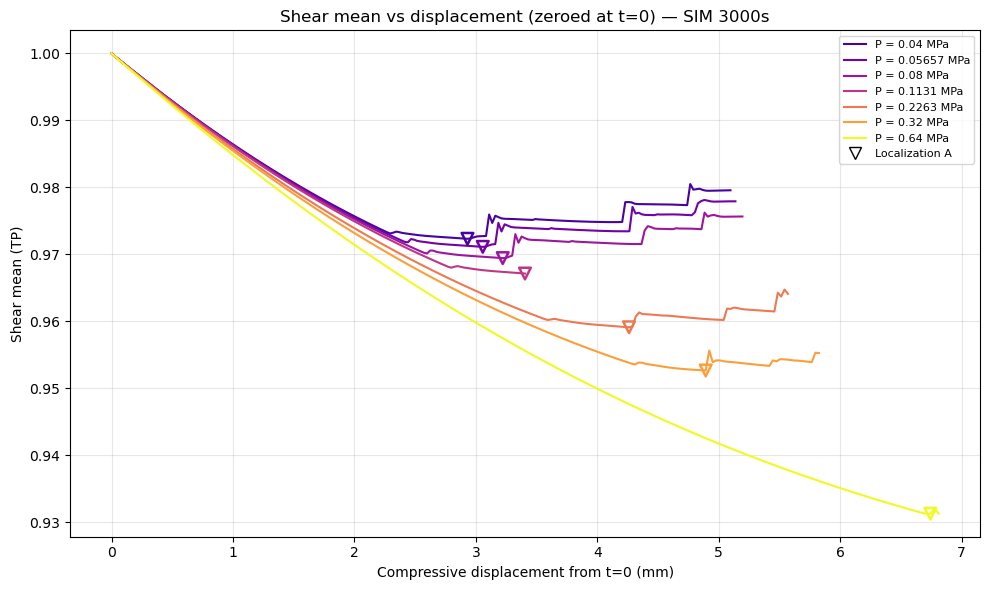

In [33]:
fig, ax = plt.subplots(figsize=(10, 6))
cmap = plt.get_cmap('plasma', len(SIMS))

for idx, sim in enumerate(SIMS):
    if sim not in SHEAR_CACHE:
        continue
    a2 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
    if a2 is None:
        continue
    displ = -np.array(a2['U2']['PERN-9999997'])
    del a2

    shear_mean = SHEAR_CACHE[sim]['shear_mean']

    # Zeroed displacement: subtract displ(t=0) so every sim starts at 0,
    # removing the pressure-induced Step-0 expansion offset.
    displ0     = displ[0]
    displ_zero = displ - displ0

    ax.plot(displ_zero, shear_mean, color=cmap(idx), label=f'P = {PRESSURES[sim]:.4g} MPa')
    if sim in LOC_A:
        xA = LOC_A[sim] - displ0
        yA = np.interp(xA, displ_zero, shear_mean)
        ax.scatter(xA, yA, marker='v', s=70, facecolor='none',
                   edgecolor=cmap(idx), linewidths=1.8, zorder=5)

ax.set_xlabel('Compressive displacement from t=0 (mm)')
ax.set_ylabel('Shear mean (TP)')
ax.set_title('Shear mean vs displacement (zeroed at t=0) — SIM 3000s')
ax.legend(*add_localization_legend(ax), loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## Plot 2 — Standard deviation of shear (TP) vs compressive displacement from t=0

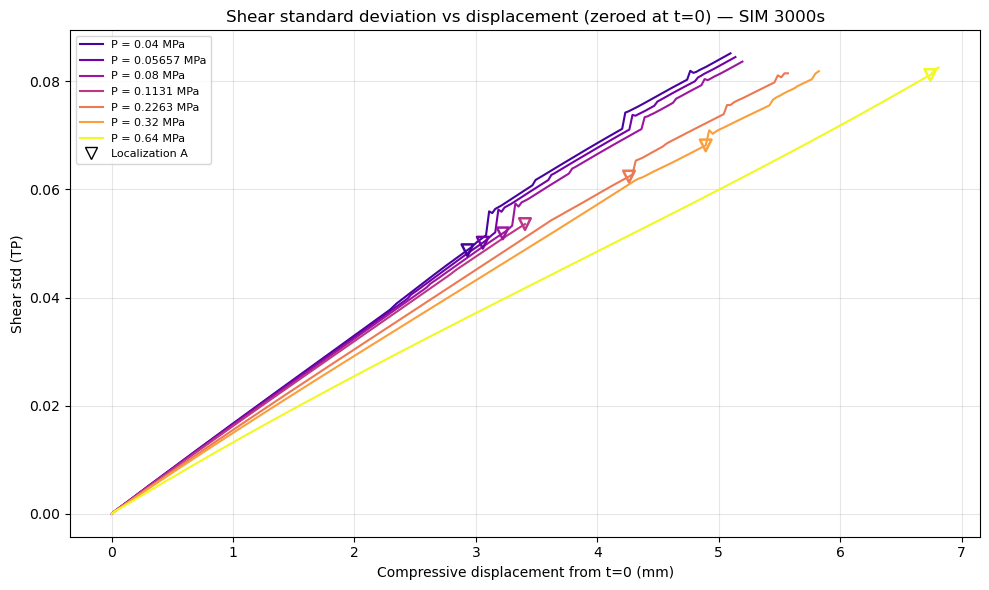

In [34]:
fig, ax = plt.subplots(figsize=(10, 6))
cmap = plt.get_cmap('plasma', len(SIMS))

for idx, sim in enumerate(SIMS):
    if sim not in SHEAR_CACHE:
        continue
    a2 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
    if a2 is None:
        continue
    displ = -np.array(a2['U2']['PERN-9999997'])
    del a2

    shear_std = SHEAR_CACHE[sim]['shear_std']

    displ0     = displ[0]
    displ_zero = displ - displ0

    ax.plot(displ_zero, shear_std, color=cmap(idx), label=f'P = {PRESSURES[sim]:.4g} MPa')
    if sim in LOC_A:
        xA = LOC_A[sim] - displ0
        yA = np.interp(xA, displ_zero, shear_std)
        ax.scatter(xA, yA, marker='v', s=70, facecolor='none',
                   edgecolor=cmap(idx), linewidths=1.8, zorder=5)

ax.set_xlabel('Compressive displacement from t=0 (mm)')
ax.set_ylabel('Shear std (TP)')
ax.set_title('Shear standard deviation vs displacement (zeroed at t=0) — SIM 3000s')
ax.legend(*add_localization_legend(ax), loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## Plot 3 — d(Shear mean)/d(displacement) vs compressive displacement from t=0

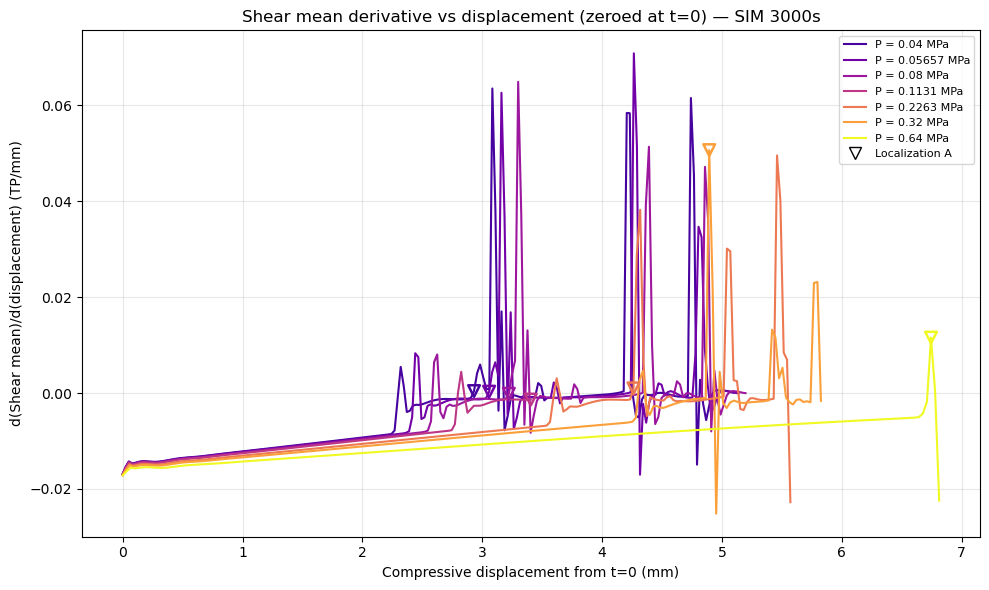

In [35]:
fig, ax = plt.subplots(figsize=(10, 6))
cmap = plt.get_cmap('plasma', len(SIMS))

for idx, sim in enumerate(SIMS):
    if sim not in SHEAR_CACHE:
        continue
    a2 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
    if a2 is None:
        continue
    displ = -np.array(a2['U2']['PERN-9999997'])
    del a2

    shear_mean = SHEAR_CACHE[sim]['shear_mean']

    displ0     = displ[0]
    displ_zero = displ - displ0
    dshear_dd  = np.gradient(shear_mean, displ_zero)

    ax.plot(displ_zero, dshear_dd, color=cmap(idx), label=f'P = {PRESSURES[sim]:.4g} MPa')
    if sim in LOC_A:
        xA = LOC_A[sim] - displ0
        yA = np.interp(xA, displ_zero, dshear_dd)
        ax.scatter(xA, yA, marker='v', s=70, facecolor='none',
                   edgecolor=cmap(idx), linewidths=1.8, zorder=5)

ax.set_xlabel('Compressive displacement from t=0 (mm)')
ax.set_ylabel('d(Shear mean)/d(displacement) (TP/mm)')
ax.set_title('Shear mean derivative vs displacement (zeroed at t=0) — SIM 3000s')
ax.legend(*add_localization_legend(ax), loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## Plot 4 — d(Shear std)/d(displacement) vs compressive displacement from t=0

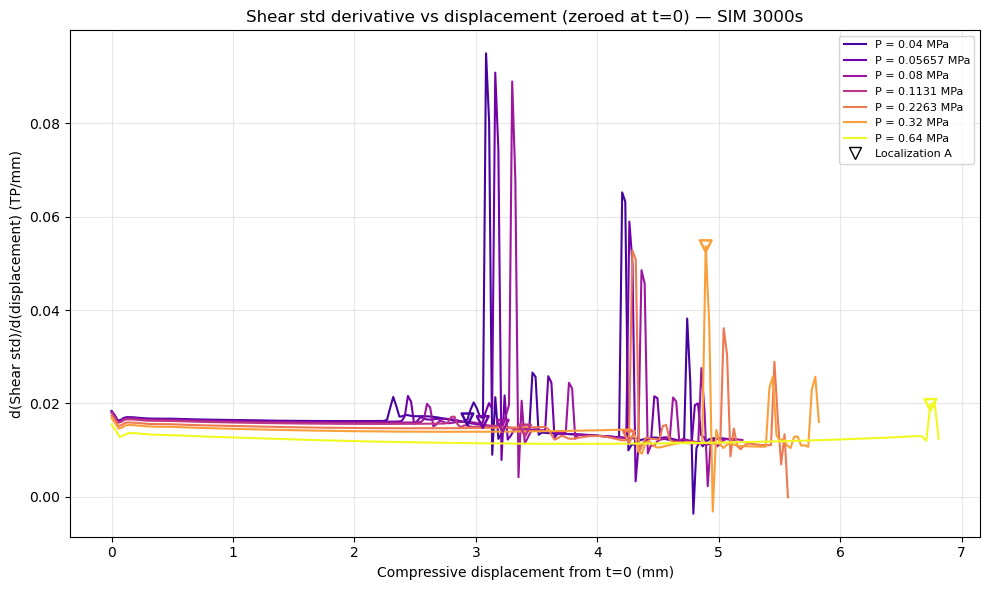

In [36]:
fig, ax = plt.subplots(figsize=(10, 6))
cmap = plt.get_cmap('plasma', len(SIMS))

for idx, sim in enumerate(SIMS):
    if sim not in SHEAR_CACHE:
        continue
    a2 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
    if a2 is None:
        continue
    displ = -np.array(a2['U2']['PERN-9999997'])
    del a2

    shear_std = SHEAR_CACHE[sim]['shear_std']

    displ0     = displ[0]
    displ_zero = displ - displ0
    dstd_dd    = np.gradient(shear_std, displ_zero)

    ax.plot(displ_zero, dstd_dd, color=cmap(idx), label=f'P = {PRESSURES[sim]:.4g} MPa')
    if sim in LOC_A:
        xA = LOC_A[sim] - displ0
        yA = np.interp(xA, displ_zero, dstd_dd)
        ax.scatter(xA, yA, marker='v', s=70, facecolor='none',
                   edgecolor=cmap(idx), linewidths=1.8, zorder=5)

ax.set_xlabel('Compressive displacement from t=0 (mm)')
ax.set_ylabel('d(Shear std)/d(displacement) (TP/mm)')
ax.set_title('Shear std derivative vs displacement (zeroed at t=0) — SIM 3000s')
ax.legend(*add_localization_legend(ax), loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## J / distortion cache

`shear_e(t) = 0.5 * trace(F_e(t)^T F_e(t)) = 0.5*(lambda1^2 + lambda2^2)`, where
lambda1, lambda2 are the singular values (principal stretches) of the per-element
deformation gradient `F_e(t)`. `J_e(t) = det(F_e(t)) = lambda1*lambda2` is already
stored per-element in the full `DATA_PICK_{sim}_TP2.pkl` (key `'J'`), alongside `'shear'`.

Decomposing shear into a dilatational part (J) and a distortional part:

```
distortion = 1/2 * (lambda1 - lambda2)^2
           = 1/2 * (lambda1^2 + lambda2^2) - lambda1*lambda2
           = shear - |J|
```

so `shear = |J| + distortion` — no extra SVD of `F` is needed, `distortion` is read off
directly from the `shear` and `J` fields already in the full TP2 pickle (verified against
an explicit `np.linalg.svd` decomposition of `F`).

Same approach as the shear/std cache above: computed once per sim from the full
`DATA_PICK_{sim}_TP2.pkl` and cached to `J_distortion_cache_3000s.pkl` next to this
notebook.

In [ ]:
J_DISTORTION_CACHE_PATH = 'J_distortion_cache_3000s.pkl'

def compute_J_distortion_cache(sims=None):
    cache = {}
    for sim in (SIMS if sims is None else sims):
        path = resolve_path(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_TP2.pkl'))
        if path is None:
            print(f'SIM {sim}: no full TP2.pkl, skipping')
            continue
        print(f'SIM {sim}: loading full TP2.pkl (~3 GB, this can take ~30-60s)...')
        with open(path, 'rb') as f:
            tp2 = pickle.load(f)

        t        = np.array(tp2['t'])
        shear    = tp2['shear']
        J        = tp2['J']
        n_frames = len(t)
        elem_ids = list(shear.keys())

        shear_arr = np.empty((len(elem_ids), n_frames))
        J_arr     = np.empty((len(elem_ids), n_frames))
        for i, eid in enumerate(elem_ids):
            sd = shear[eid]
            jd = J[eid]
            shear_arr[i, :] = [sd[j] for j in range(n_frames)]
            J_arr[i, :]     = [jd[j] for j in range(n_frames)]
        del tp2, shear, J

        distortion_arr = shear_arr - np.abs(J_arr)

        cache[sim] = {
            't'               : t,
            'shear_mean'      : shear_arr.mean(axis=0),
            'J_mean'          : J_arr.mean(axis=0),
            'distortion_mean' : distortion_arr.mean(axis=0),
        }
        del shear_arr, J_arr, distortion_arr
        print(f'SIM {sim}: done')
    return cache


# Incremental: load whatever is cached, then compute ONLY the sims still missing.
# (A cache written while results were absent used to pin itself empty forever.)
J_DISTORTION_CACHE = {}
if os.path.exists(J_DISTORTION_CACHE_PATH):
    with open(J_DISTORTION_CACHE_PATH, 'rb') as f:
        J_DISTORTION_CACHE = pickle.load(f)
_missing = [s for s in SIMS if s not in J_DISTORTION_CACHE]
if _missing:
    print(f'cache {J_DISTORTION_CACHE_PATH}: have {sorted(J_DISTORTION_CACHE)}, trying {_missing}')
    J_DISTORTION_CACHE.update(compute_J_distortion_cache(_missing))
    with open(J_DISTORTION_CACHE_PATH, 'wb') as f:
        pickle.dump(J_DISTORTION_CACHE, f)
print(f'J_DISTORTION_CACHE: {sorted(J_DISTORTION_CACHE)}')


cache J_distortion_cache_3000s.pkl: have [3001, 3002, 3003, 3004, 3006, 3007, 3009], trying [3000, 3005, 3008]
SIM 3000: no full TP2.pkl, skipping
SIM 3005: no full TP2.pkl, skipping
SIM 3008: no full TP2.pkl, skipping
J_DISTORTION_CACHE: [3001, 3002, 3003, 3004, 3006, 3007, 3009]


## Plot 5 — J mean (dilatational part) vs compressive displacement from t=0

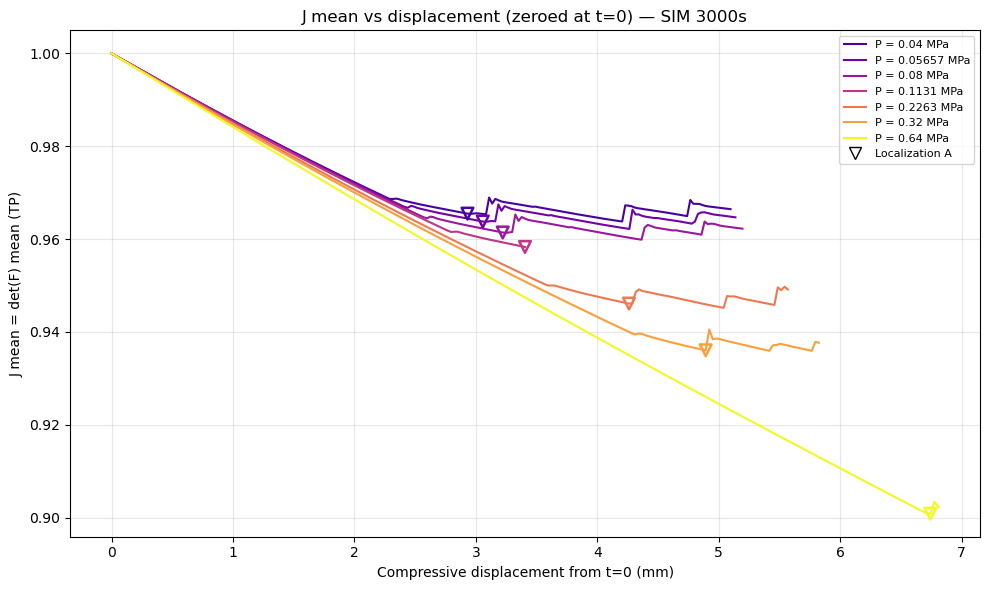

In [38]:
fig, ax = plt.subplots(figsize=(10, 6))
cmap = plt.get_cmap('plasma', len(SIMS))

for idx, sim in enumerate(SIMS):
    if sim not in J_DISTORTION_CACHE:
        continue
    a2 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
    if a2 is None:
        continue
    displ = -np.array(a2['U2']['PERN-9999997'])
    del a2

    J_mean = J_DISTORTION_CACHE[sim]['J_mean']

    displ0     = displ[0]
    displ_zero = displ - displ0

    ax.plot(displ_zero, J_mean, color=cmap(idx), label=f'P = {PRESSURES[sim]:.4g} MPa')
    if sim in LOC_A:
        xA = LOC_A[sim] - displ0
        yA = np.interp(xA, displ_zero, J_mean)
        ax.scatter(xA, yA, marker='v', s=70, facecolor='none',
                   edgecolor=cmap(idx), linewidths=1.8, zorder=5)

ax.set_xlabel('Compressive displacement from t=0 (mm)')
ax.set_ylabel('J mean = det(F) mean (TP)')
ax.set_title('J mean vs displacement (zeroed at t=0) — SIM 3000s')
ax.legend(*add_localization_legend(ax), loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## Plot 6 — Distortion mean (distortional part) vs compressive displacement from t=0

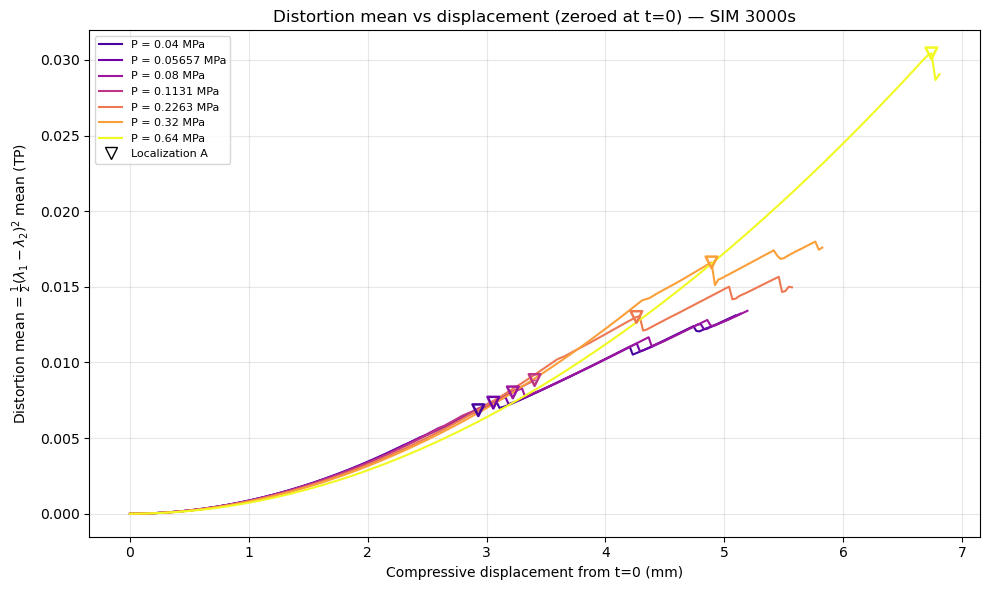

In [39]:
fig, ax = plt.subplots(figsize=(10, 6))
cmap = plt.get_cmap('plasma', len(SIMS))

for idx, sim in enumerate(SIMS):
    if sim not in J_DISTORTION_CACHE:
        continue
    a2 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
    if a2 is None:
        continue
    displ = -np.array(a2['U2']['PERN-9999997'])
    del a2

    distortion_mean = J_DISTORTION_CACHE[sim]['distortion_mean']

    displ0     = displ[0]
    displ_zero = displ - displ0

    ax.plot(displ_zero, distortion_mean, color=cmap(idx), label=f'P = {PRESSURES[sim]:.4g} MPa')
    if sim in LOC_A:
        xA = LOC_A[sim] - displ0
        yA = np.interp(xA, displ_zero, distortion_mean)
        ax.scatter(xA, yA, marker='v', s=70, facecolor='none',
                   edgecolor=cmap(idx), linewidths=1.8, zorder=5)

ax.set_xlabel('Compressive displacement from t=0 (mm)')
ax.set_ylabel(r'Distortion mean = $\frac{1}{2}(\lambda_1-\lambda_2)^2$ mean (TP)')
ax.set_title('Distortion mean vs displacement (zeroed at t=0) — SIM 3000s')
ax.legend(*add_localization_legend(ax), loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## Plot 7 — eta_shear (area-weighted shear homogeneity) vs compressive displacement from t=0

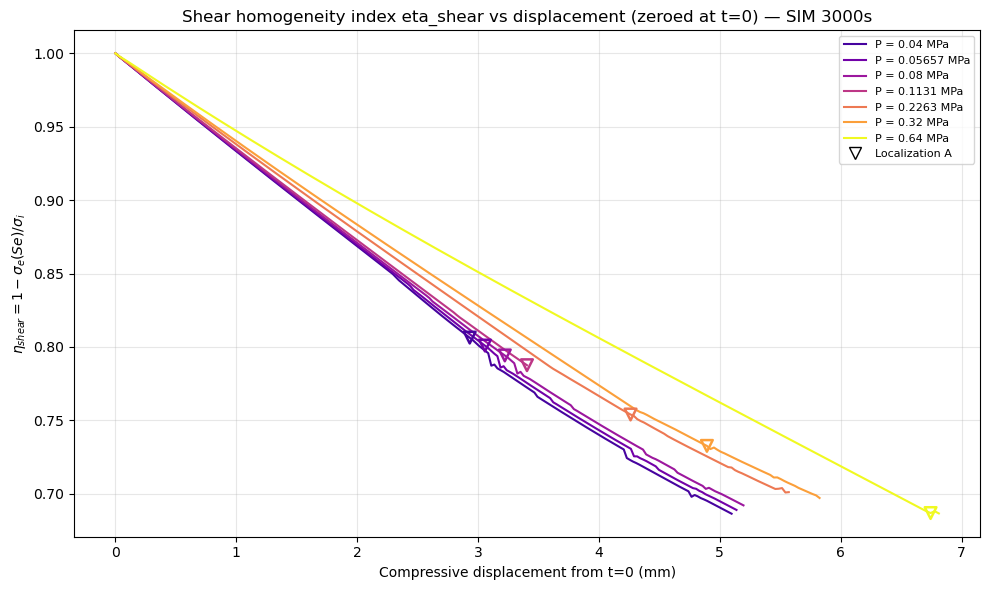

In [40]:
fig, ax = plt.subplots(figsize=(10, 6))
cmap = plt.get_cmap('plasma', len(SIMS))

for idx, sim in enumerate(SIMS):
    a2   = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
    tp2l = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_TP2_L.pkl'))
    if a2 is None or tp2l is None:
        del a2, tp2l
        continue
    displ      = -np.array(a2['U2']['PERN-9999997'])
    eta_shear  = np.array(tp2l['eta_shear'])
    del a2, tp2l

    displ0     = displ[0]
    displ_zero = displ - displ0

    ax.plot(displ_zero, eta_shear, color=cmap(idx), label=f'P = {PRESSURES[sim]:.4g} MPa')
    if sim in LOC_A:
        xA = LOC_A[sim] - displ0
        yA = np.interp(xA, displ_zero, eta_shear)
        ax.scatter(xA, yA, marker='v', s=70, facecolor='none',
                   edgecolor=cmap(idx), linewidths=1.8, zorder=5)

ax.set_xlabel('Compressive displacement from t=0 (mm)')
ax.set_ylabel(r'$\eta_{shear} = 1 - \sigma_e(Se)/\sigma_i$')
ax.set_title('Shear homogeneity index eta_shear vs displacement (zeroed at t=0) — SIM 3000s')
ax.legend(*add_localization_legend(ax), loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## Plot 8 — eta (element-area homogeneity) vs compressive displacement from t=0

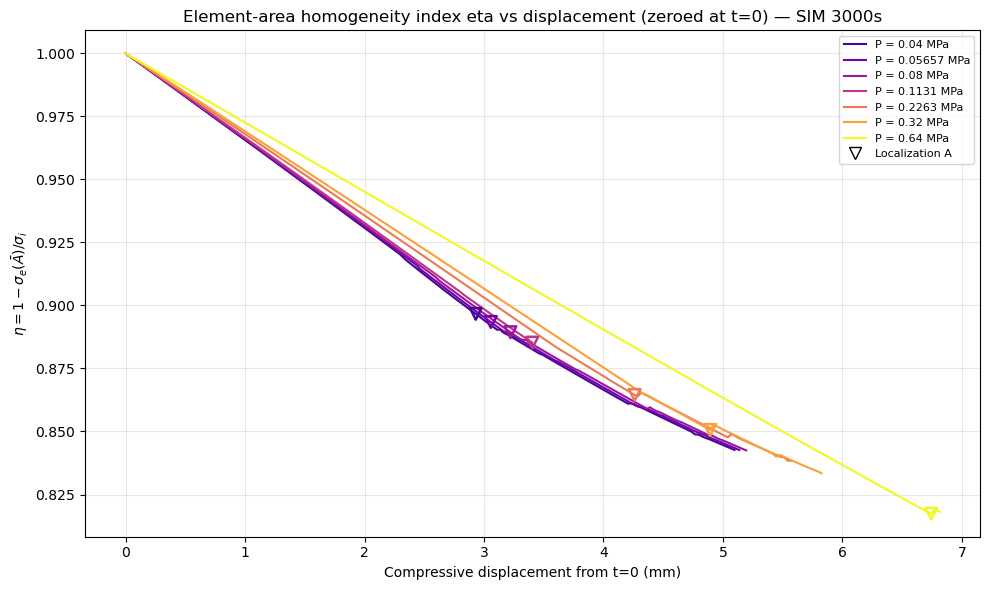

In [41]:
fig, ax = plt.subplots(figsize=(10, 6))
cmap = plt.get_cmap('plasma', len(SIMS))

for idx, sim in enumerate(SIMS):
    a2   = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
    tp2l = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_TP2_L.pkl'))
    if a2 is None or tp2l is None:
        del a2, tp2l
        continue
    displ = -np.array(a2['U2']['PERN-9999997'])
    eta   = np.array(tp2l['eta'])
    del a2, tp2l

    displ0     = displ[0]
    displ_zero = displ - displ0

    ax.plot(displ_zero, eta, color=cmap(idx), label=f'P = {PRESSURES[sim]:.4g} MPa')
    if sim in LOC_A:
        xA = LOC_A[sim] - displ0
        yA = np.interp(xA, displ_zero, eta)
        ax.scatter(xA, yA, marker='v', s=70, facecolor='none',
                   edgecolor=cmap(idx), linewidths=1.8, zorder=5)

ax.set_xlabel('Compressive displacement from t=0 (mm)')
ax.set_ylabel(r'$\eta = 1 - \sigma_e(\bar{A})/\sigma_i$')
ax.set_title('Element-area homogeneity index eta vs displacement (zeroed at t=0) — SIM 3000s')
ax.legend(*add_localization_legend(ax), loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## Plot 9 — etaC_A, etaC_R (hole-based localization indices) vs compressive displacement from t=0

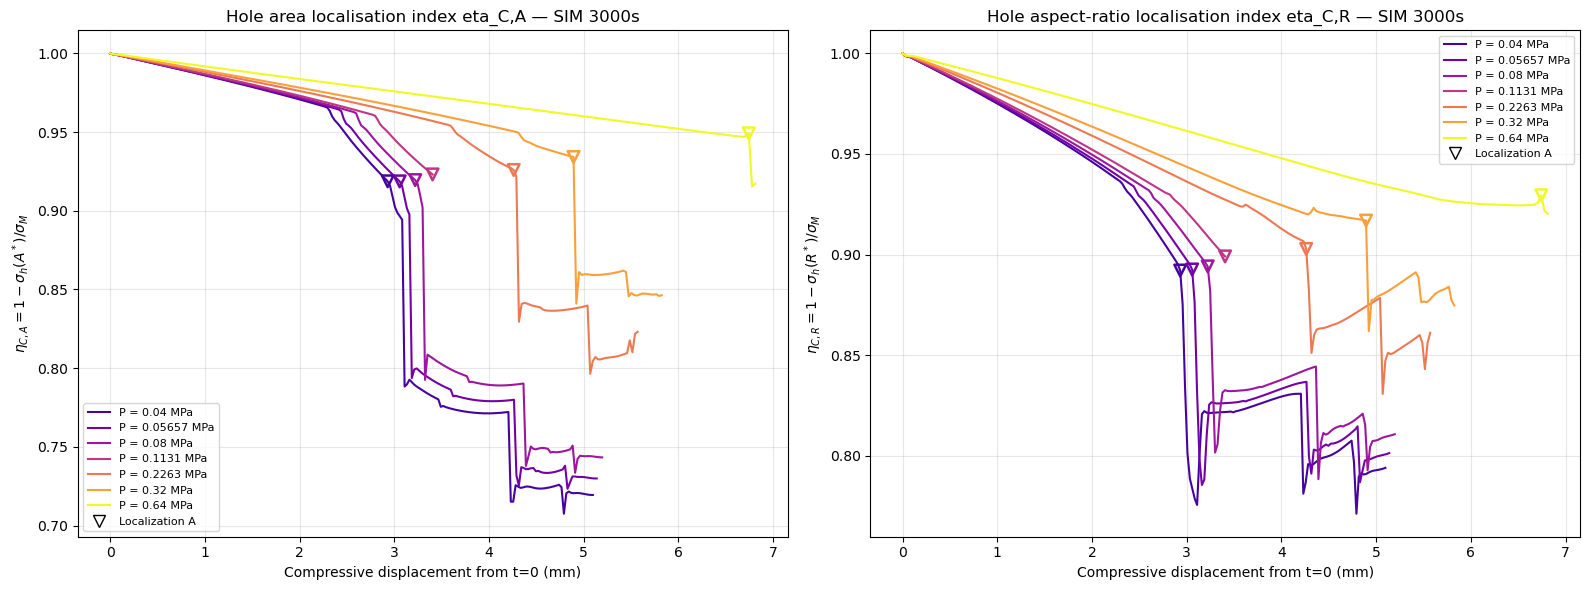

In [42]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
cmap = plt.get_cmap('plasma', len(SIMS))

for idx, sim in enumerate(SIMS):
    defc2 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_DEFC2.pkl'))
    if defc2 is None:
        continue
    # displacement here matches A2's U2 sign convention (signed, decreasing).
    displ  = -np.array(defc2['displacement'])
    etaC_A = np.array(defc2['etaC_A'])
    etaC_R = np.array(defc2['etaC_R'])
    del defc2

    displ0     = displ[0]
    displ_zero = displ - displ0

    ax1.plot(displ_zero, etaC_A, color=cmap(idx), label=f'P = {PRESSURES[sim]:.4g} MPa')
    ax2.plot(displ_zero, etaC_R, color=cmap(idx), label=f'P = {PRESSURES[sim]:.4g} MPa')
    if sim in LOC_A:
        xA = LOC_A[sim] - displ0
        yA1 = np.interp(xA, displ_zero, etaC_A)
        yA2 = np.interp(xA, displ_zero, etaC_R)
        ax1.scatter(xA, yA1, marker='v', s=70, facecolor='none',
                    edgecolor=cmap(idx), linewidths=1.8, zorder=5)
        ax2.scatter(xA, yA2, marker='v', s=70, facecolor='none',
                    edgecolor=cmap(idx), linewidths=1.8, zorder=5)

ax1.set_xlabel('Compressive displacement from t=0 (mm)')
ax1.set_ylabel(r'$\eta_{C,A} = 1 - \sigma_h(A^*)/\sigma_M$')
ax1.set_title('Hole area localisation index eta_C,A — SIM 3000s')
ax1.legend(*add_localization_legend(ax1), loc='best', fontsize=8)
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Compressive displacement from t=0 (mm)')
ax2.set_ylabel(r'$\eta_{C,R} = 1 - \sigma_h(R^*)/\sigma_M$')
ax2.set_title('Hole aspect-ratio localisation index eta_C,R — SIM 3000s')
ax2.legend(*add_localization_legend(ax2), loc='best', fontsize=8)
ax2.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()


## Plot 10 — w_cv (strain-energy-density coefficient of variation) vs compressive displacement from t=0

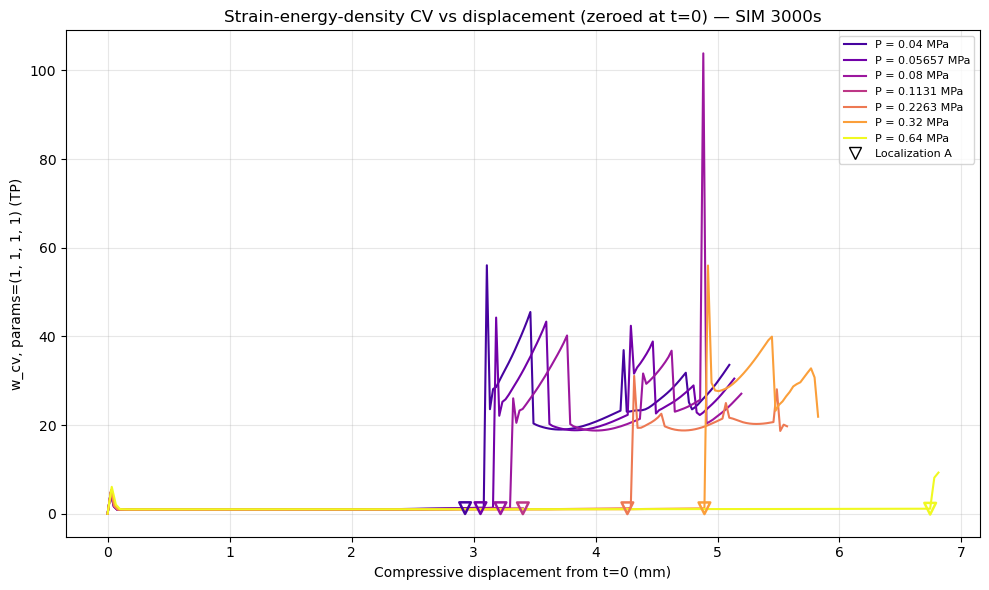

In [43]:
fig, ax = plt.subplots(figsize=(10, 6))
cmap = plt.get_cmap('plasma', len(SIMS))
W_PARAMS = (1, 1, 1, 1)

for idx, sim in enumerate(SIMS):
    a2   = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
    tp2l = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_TP2_L.pkl'))
    if a2 is None or tp2l is None:
        del a2, tp2l
        continue
    displ = -np.array(a2['U2']['PERN-9999997'])
    w_cv  = np.array(tp2l['w_cv'][W_PARAMS])
    del a2, tp2l

    displ0     = displ[0]
    displ_zero = displ - displ0

    ax.plot(displ_zero, w_cv, color=cmap(idx), label=f'P = {PRESSURES[sim]:.4g} MPa')
    if sim in LOC_A:
        xA = LOC_A[sim] - displ0
        yA = np.interp(xA, displ_zero, w_cv)
        ax.scatter(xA, yA, marker='v', s=70, facecolor='none',
                   edgecolor=cmap(idx), linewidths=1.8, zorder=5)

ax.set_xlabel('Compressive displacement from t=0 (mm)')
ax.set_ylabel(f'w_cv, params={W_PARAMS} (TP)')
ax.set_title('Strain-energy-density CV vs displacement (zeroed at t=0) — SIM 3000s')
ax.legend(*add_localization_legend(ax), loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## Plot 11 — f (tension/compression network efficiency ratio) vs compressive strain from t=0

`f(t) = global_ef_t(t) / global_ef_c(t)` from `DATA_PICK_{sim}_I3_BFS_3002.pkl` — the
ratio of average global efficiency of the tension bar network to the compression bar
network on the hexagonal overlay lattice. `f = 1` marks the frame where the skeleton's
mean stress crosses zero (see `docs/PRESSURE_LIMIT_STRAIN_AND_FACTOR_F.md`). Plotted on
a log y-axis since `f` spans several orders of magnitude within a run.

Strain uses the same zeroed convention as `SIM_3000s_analysis.ipynb`:
`strain = (displ - displ[0]) / (20 - displ[0])`, where `20 - displ[0]` is the specimen
height at the start of Step-1 (post pressure-expansion, pre-loading).

SIM 3000 (P = 0) is excluded from the `f = 1` story (`f(0) = 0` there, see doc caveat)
but is still plotted.

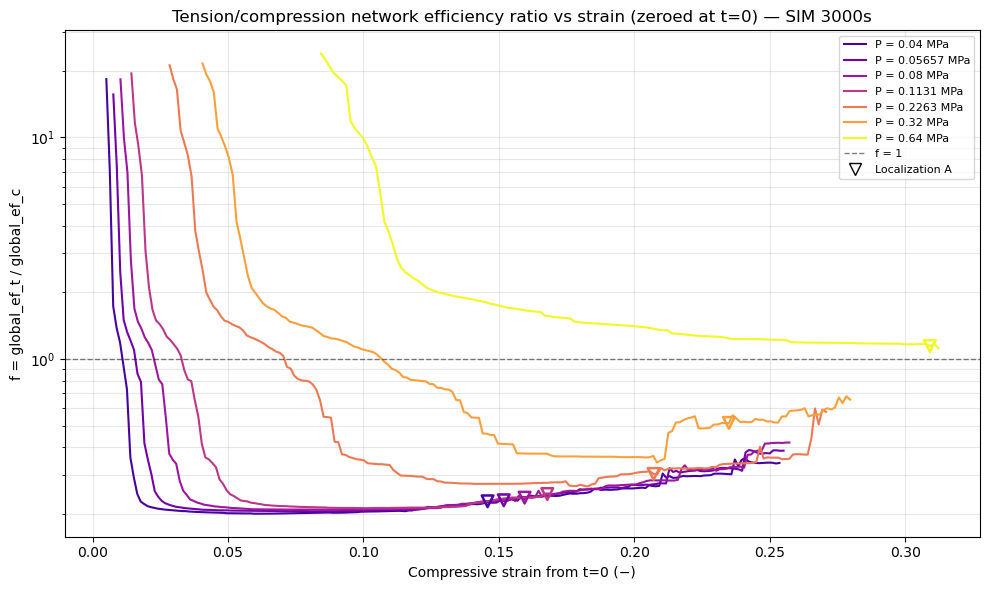

In [44]:
fig, ax = plt.subplots(figsize=(10, 6))
cmap = plt.get_cmap('plasma', len(SIMS))

for idx, sim in enumerate(SIMS):
    a2  = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
    i3  = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_I3_BFS_3002.pkl'))
    if a2 is None or i3 is None:
        del a2, i3
        continue
    displ = -np.array(a2['U2']['PERN-9999997'])
    ef_t  = np.array(i3['global_ef_t'], dtype=float)
    ef_c  = np.array(i3['global_ef_c'], dtype=float)
    del a2, i3

    with np.errstate(divide='ignore', invalid='ignore'):
        f_ratio = np.where(ef_c != 0, ef_t / ef_c, np.nan)
    del ef_t, ef_c

    # Compressive displacement from t=0, and the corresponding strain.
    # Original height at the start of Step-1 (post pressure-expansion,
    # pre-loading) = 20 - displ(t=0), since displ(t=0) is negative/zero.
    displ0     = displ[0]
    displ_zero = displ - displ0
    height0    = 20 - displ0
    strain     = displ_zero / height0

    mask = ~np.isnan(f_ratio) & (displ > 0)
    ax.plot(strain[mask], f_ratio[mask], color=cmap(idx), label=f'P = {PRESSURES[sim]:.4g} MPa')
    if sim in LOC_A:
        xA = (LOC_A[sim] - displ0) / height0
        yA = np.interp(xA, strain[mask], f_ratio[mask])
        ax.scatter(xA, yA, marker='v', s=70, facecolor='none',
                   edgecolor=cmap(idx), linewidths=1.8, zorder=5)

ax.axhline(1.0, color='k', linestyle='--', linewidth=1, alpha=0.5, label='f = 1')
ax.set_yscale('log')
ax.set_xlabel('Compressive strain from t=0 (−)')
ax.set_ylabel('f = global_ef_t / global_ef_c')
ax.set_title('Tension/compression network efficiency ratio vs strain (zeroed at t=0) — SIM 3000s')
ax.legend(*add_localization_legend(ax), loc='best', fontsize=8)
ax.grid(True, alpha=0.3, which='both')
fig.tight_layout()
plt.show()


## Plot 12 — P/E vs strain at f = 1 (per sim)

`f = 1` marks the frame where the skeleton's mean stress crosses zero (the tension
backbone and compression backbone have equal global efficiency) — see
`docs/PRESSURE_LIMIT_STRAIN_AND_FACTOR_F.md` §2 (derived from the 1010s family; treat
as a prior, not a guarantee, for the 3000s pressure sweep). For each sim, `eps(f=1)` is
found by walking the strain-ordered `f` curve and linearly interpolating the strain at
the first frame-to-frame crossing from `f >= 1` to `f < 1`.

`E` is read per sim from `OBJ_files/SIM_{sim}.json` (constant at 20 across this sweep).
If SIM 3000 (P = 0) never crosses `f = 1` — as SIM 1010 did not, see doc §6 caveat — it
is excluded from this fit automatically (`eps_f1 is None` skips it).


In [45]:
def get_E(sim):
    path = resolve_path(os.path.join(OBJ_DIR, f'SIM_{sim:03d}.json'))
    if path is None:
        return None
    with open(path) as f:
        d = json.load(f)
    return float(d['E'])

loc_f1_data = []
for sim in SIMS:
    a2 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
    i3 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_I3_BFS_3002.pkl'))
    E  = get_E(sim)
    if a2 is None or i3 is None or sim not in PRESSURES or E is None:
        del a2, i3
        continue
    displ = -np.array(a2['U2']['PERN-9999997'])
    ef_t  = np.array(i3['global_ef_t'], dtype=float)
    ef_c  = np.array(i3['global_ef_c'], dtype=float)
    del a2, i3

    with np.errstate(divide='ignore', invalid='ignore'):
        f_ratio = np.where(ef_c != 0, ef_t / ef_c, np.nan)
    del ef_t, ef_c

    mask = ~np.isnan(f_ratio) & (displ > 0)
    displ_m, f_m = displ[mask], f_ratio[mask]

    displ0  = displ[0]
    height0 = 20 - displ0
    strain_m = (displ_m - displ0) / height0

    # First frame-to-frame crossing from f >= 1 down to f < 1, linearly
    # interpolated in strain. None if f never crosses 1 (e.g. SIM 3000).
    eps_f1 = None
    for i in range(len(f_m) - 1):
        if f_m[i] >= 1 and f_m[i + 1] < 1:
            frac = (1 - f_m[i]) / (f_m[i + 1] - f_m[i])
            eps_f1 = strain_m[i] + frac * (strain_m[i + 1] - strain_m[i])
            break
    if eps_f1 is None:
        continue

    P = PRESSURES[sim]
    loc_f1_data.append(dict(sim=sim, P=P, E=E, P_over_E=P / E, eps_f1=eps_f1))

loc_f1_data.sort(key=lambda d: d['P_over_E'])
loc_f1_data


[{'sim': 3001,
  'P': 0.04,
  'E': 20.0,
  'P_over_E': 0.002,
  'eps_f1': 0.011072455111909504},
 {'sim': 3002,
  'P': 0.05656854249492381,
  'E': 20.0,
  'P_over_E': 0.0028284271247461905,
  'eps_f1': 0.01583076371445846},
 {'sim': 3003,
  'P': 0.08000000000000002,
  'E': 20.0,
  'P_over_E': 0.004000000000000001,
  'eps_f1': 0.022686272163230173},
 {'sim': 3004,
  'P': 0.11313708498984763,
  'E': 20.0,
  'P_over_E': 0.005656854249492382,
  'eps_f1': 0.032887711286032593},
 {'sim': 3006,
  'P': 0.2262741699796953,
  'E': 20.0,
  'P_over_E': 0.011313708498984765,
  'eps_f1': 0.07082184666200192},
 {'sim': 3007,
  'P': 0.3200000000000002,
  'E': 20.0,
  'P_over_E': 0.016000000000000007,
  'eps_f1': 0.10677862138477642}]

### Plot 12 (figure)

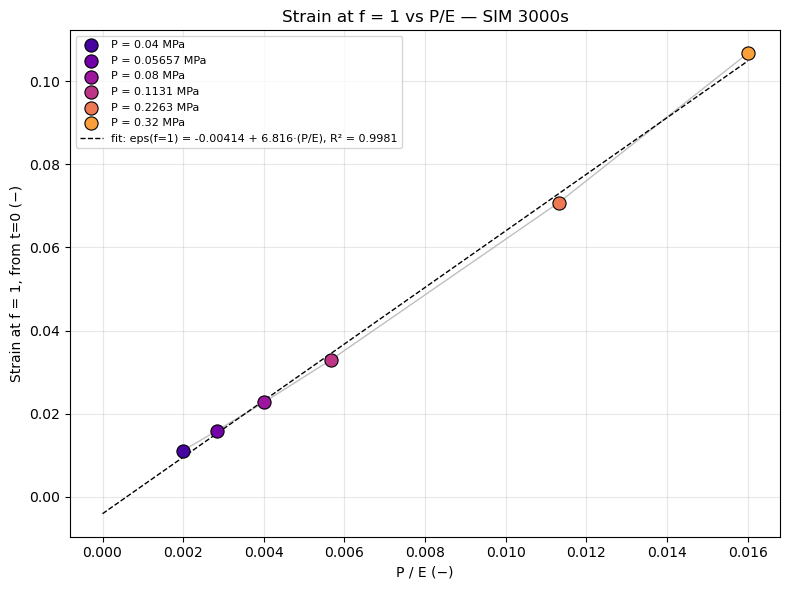

In [46]:
def plot_f1_fit():
    if len(loc_f1_data) < 2:
        print(f'Plot 12 skipped: need at least 2 f=1 crossings, found {len(loc_f1_data)}.')
        return
    fig, ax = plt.subplots(figsize=(8, 6))
    cmap = plt.get_cmap('plasma', len(SIMS))
    
    for idx, sim in enumerate(SIMS):
        d = next((d for d in loc_f1_data if d['sim'] == sim), None)
        if d is None:
            continue
        ax.scatter(d['P_over_E'], d['eps_f1'], marker='o', s=90, color=cmap(idx),
                   edgecolor='k', linewidths=0.8, zorder=5,
                   label=f'P = {PRESSURES[sim]:.4g} MPa')
    
    x = np.array([d['P_over_E'] for d in loc_f1_data])
    y = np.array([d['eps_f1'] for d in loc_f1_data])
    ax.plot(x, y, color='gray', linestyle='-', linewidth=1, alpha=0.5, zorder=1)
    
    slope, intercept = np.polyfit(x, y, 1)
    r2 = 1 - np.sum((y - (slope * x + intercept))**2) / np.sum((y - y.mean())**2)
    xfit = np.linspace(0, x.max(), 50)
    ax.plot(xfit, slope * xfit + intercept, color='k', linestyle='--', linewidth=1,
            label=f'fit: eps(f=1) = {intercept:.4g} + {slope:.4g}·(P/E), R² = {r2:.4f}')
    
    ax.set_xlabel('P / E (−)')
    ax.set_ylabel('Strain at f = 1, from t=0 (−)')
    ax.set_title('Strain at f = 1 vs P/E — SIM 3000s')
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()

plot_f1_fit()


## p (mean skeleton pressure) cache

`p_e(t) = -(S11_e(t) + S22_e(t)) / 2` per FEM element, from the raw `DATA_PICK_{sim}_B.pkl`
(Abaqus element stresses, integration-point resolved). Positive in compression, negative
in tension — same sign convention as `p0`/`p*` in `docs/SHEAR_PARAMETER_INTERPRETATION.md`.

`B.pkl` stores 8 rows per element (section-point duplicates of up to 4 integration
points, stride-2 pattern — see `fem_stress_interpolation._get_stress_at_integration_points`).
Averaging rows `0,2,4,6` gives the equal-weight barycenter value for quads (CPS4) and the
single constant value for triangles (CPS3, where all 8 rows are equal). Verified against
the doc: SIM 1013 mean p at t=0 computed here is -0.1251, doc table says -0.125.

Each `B.pkl` is ~1.2 GB (55k+ elements x 8 rows x 201 frames) so this is cached to
`p_cache_3000s.pkl` after the first run (~15-20s/sim to load + reduce).

For each sim this keeps: the full `mean_p(t)` curve (population mean across all elements,
every frame) and, at 5 landmark frames, the full per-element pressure snapshot (for the
histograms below):
- `t0` — frame 0
- `epsstar` — the Localization A frame (first prominent local min of `shear_mean`, same frame as `LOC_A`)
- `f1` — the frame closest to the `f = 1` crossing (see Plot 12)
- `mid` — the temporal midpoint of the run, `len(t)//2`
- `final` — the last frame

SIM 3000 (P = 0) has no `f1` landmark (`f` never crosses 1, see Plot 11/12 caveats) and is


In [ ]:
P_CACHE_PATH = 'p_cache_3000s.pkl'

def compute_p_cache(sims=None):
    cache = {}
    for sim in (SIMS if sims is None else sims):
        b_path = resolve_path(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_B.pkl'))
        a2 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
        i3 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_I3_BFS_3002.pkl'))
        if b_path is None or a2 is None:
            print(f'SIM {sim}: missing B or A2, skipping')
            continue
        print(f'SIM {sim}: loading B.pkl (~1.2 GB, ~15-20s)...')
        with open(b_path, 'rb') as f:
            b = pickle.load(f)

        t = np.array(b['t'])
        elem_ids = list(b['S11'].keys())
        s11_all = np.array([b['S11'][e] for e in elem_ids])   # (n_elem, 8, n_frames)
        s22_all = np.array([b['S22'][e] for e in elem_ids])
        del b

        p_ip = -(s11_all[:, 0::2, :] + s22_all[:, 0::2, :]) / 2.0   # (n_elem, 4, n_frames)
        p_e  = p_ip.mean(axis=1)                                   # (n_elem, n_frames)
        del s11_all, s22_all, p_ip

        mean_p_t = p_e.mean(axis=0)

        displ = -np.array(a2['U2']['PERN-9999997'])
        del a2

        idx_t0    = 0
        idx_final = len(t) - 1
        idx_mid   = len(t) // 2

        idx_epsstar = int(np.argmin(np.abs(displ - LOC_A[sim]))) if sim in LOC_A else None

        idx_f1 = None
        if i3 is not None:
            ef_t = np.array(i3['global_ef_t'], dtype=float)
            ef_c = np.array(i3['global_ef_c'], dtype=float)
            with np.errstate(divide='ignore', invalid='ignore'):
                f_ratio = np.where(ef_c != 0, ef_t / ef_c, np.nan)
            valid = np.where(~np.isnan(f_ratio) & (displ > 0))[0]
            for k in range(len(valid) - 1):
                i0, i1 = valid[k], valid[k + 1]
                if f_ratio[i0] >= 1 and f_ratio[i1] < 1:
                    idx_f1 = int(i0 if abs(f_ratio[i0] - 1) <= abs(f_ratio[i1] - 1) else i1)
                    break

        landmarks = {'t0': idx_t0, 'epsstar': idx_epsstar, 'f1': idx_f1,
                     'mid': idx_mid, 'final': idx_final}
        snapshots = {name: (p_e[:, idx].copy() if idx is not None else None)
                     for name, idx in landmarks.items()}

        cache[sim] = dict(t=t, mean_p=mean_p_t, landmarks=landmarks, snapshots=snapshots)
        del p_e
        print(f'SIM {sim}: done')
    return cache


# Incremental: load whatever is cached, then compute ONLY the sims still missing.
# (A cache written while results were absent used to pin itself empty forever.)
P_CACHE = {}
if os.path.exists(P_CACHE_PATH):
    with open(P_CACHE_PATH, 'rb') as f:
        P_CACHE = pickle.load(f)
_missing = [s for s in SIMS if s not in P_CACHE]
if _missing:
    print(f'cache {P_CACHE_PATH}: have {sorted(P_CACHE)}, trying {_missing}')
    P_CACHE.update(compute_p_cache(_missing))
    with open(P_CACHE_PATH, 'wb') as f:
        pickle.dump(P_CACHE, f)
print(f'P_CACHE: {sorted(P_CACHE)}')


cache p_cache_3000s.pkl: have [3001, 3002, 3003, 3004, 3006, 3007, 3009], trying [3000, 3005, 3008]
SIM 3000: missing B or A2, skipping
SIM 3005: missing B or A2, skipping
SIM 3008: missing B or A2, skipping
P_CACHE: [3001, 3002, 3003, 3004, 3006, 3007, 3009]


## Plot 13 — Mean p (skeleton pressure) vs strain

Population mean of `p_e(t)` across all elements, plotted against the same zeroed strain
convention as Plots 11/12. `p < 0` at small strain for pressurized sims reflects the
biaxial pre-tension from internal gas pressure (§1/§3 of
`docs/PRESSURE_LIMIT_STRAIN_AND_FACTOR_F.md`); `p` rises through 0 as compression takes
over.

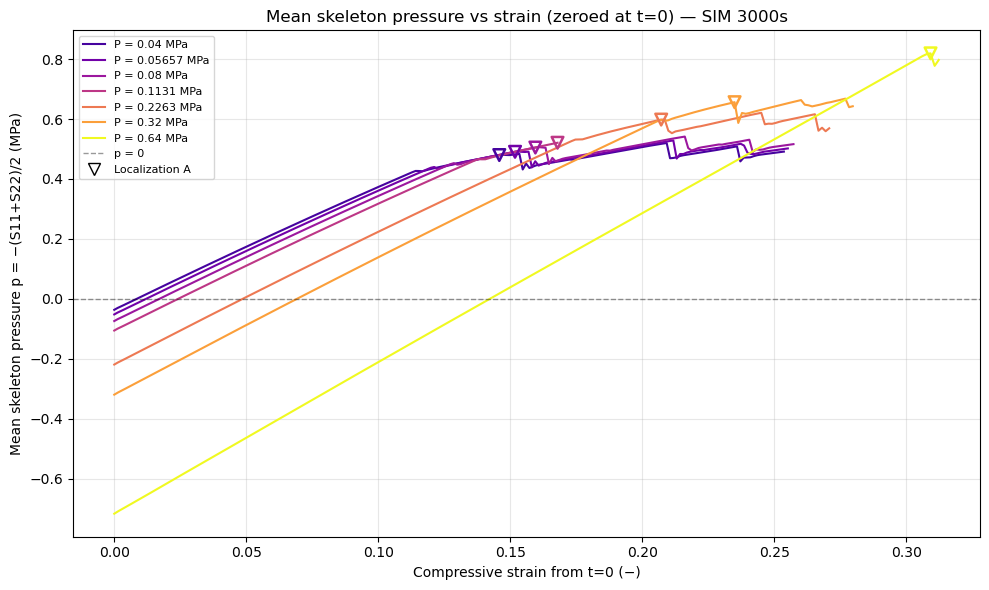

In [48]:
fig, ax = plt.subplots(figsize=(10, 6))
cmap = plt.get_cmap('plasma', len(SIMS))

for idx, sim in enumerate(SIMS):
    if sim not in P_CACHE:
        continue
    a2 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
    if a2 is None:
        continue
    displ = -np.array(a2['U2']['PERN-9999997'])
    del a2

    mean_p = P_CACHE[sim]['mean_p']

    displ0  = displ[0]
    height0 = 20 - displ0
    strain  = (displ - displ0) / height0

    ax.plot(strain, mean_p, color=cmap(idx), label=f'P = {PRESSURES[sim]:.4g} MPa')
    if sim in LOC_A:
        xA = (LOC_A[sim] - displ0) / height0
        yA = np.interp(xA, strain, mean_p)
        ax.scatter(xA, yA, marker='v', s=70, facecolor='none',
                   edgecolor=cmap(idx), linewidths=1.8, zorder=5)

ax.axhline(0.0, color='k', linestyle='--', linewidth=1, alpha=0.4, label='p = 0')
ax.set_xlabel('Compressive strain from t=0 (−)')
ax.set_ylabel('Mean skeleton pressure p = −(S11+S22)/2 (MPa)')
ax.set_title('Mean skeleton pressure vs strain (zeroed at t=0) — SIM 3000s')
ax.legend(*add_localization_legend(ax), loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## Plot 14 — Distribution of element pressure at 5 landmark frames

One figure per landmark, all 9 sims overlaid as unfilled step histograms (density-
normalized, shared bin edges per landmark), colored by pressure — same convention as
every other plot in this notebook. A dashed vertical line in each sim's color marks that
sim's mean p at the landmark (matches the `mean_p` curve in Plot 13). Landmarks: `t = 0`,
`ε = ε*` (Localization A), `f = 1`, the temporal midpoint of the run, and the final
frame. SIM 3000 has no `f = 1` landmark and is omitted from that one panel only.

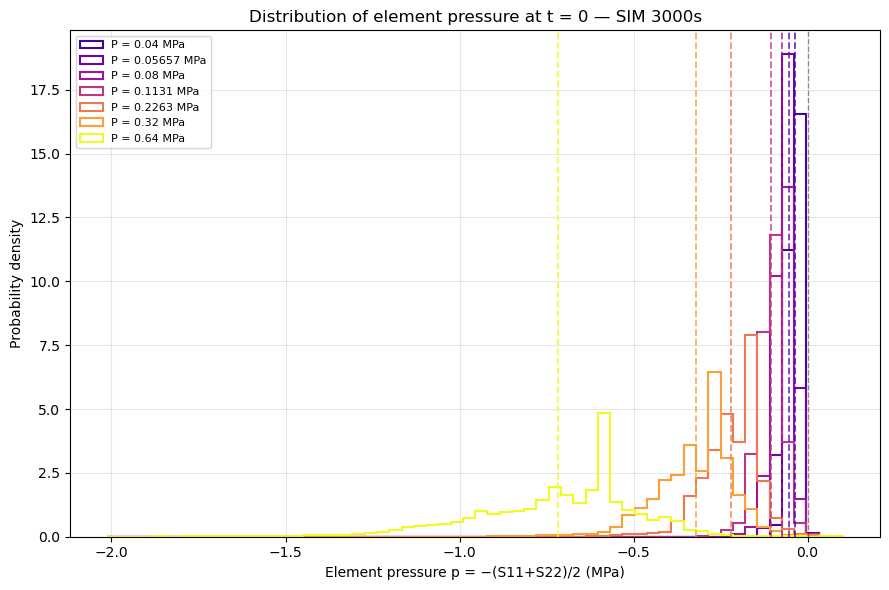

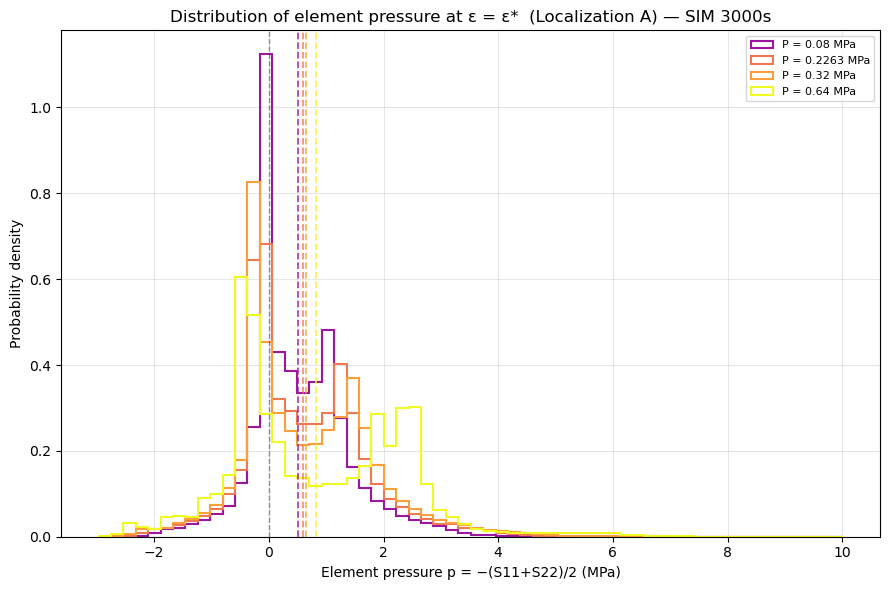

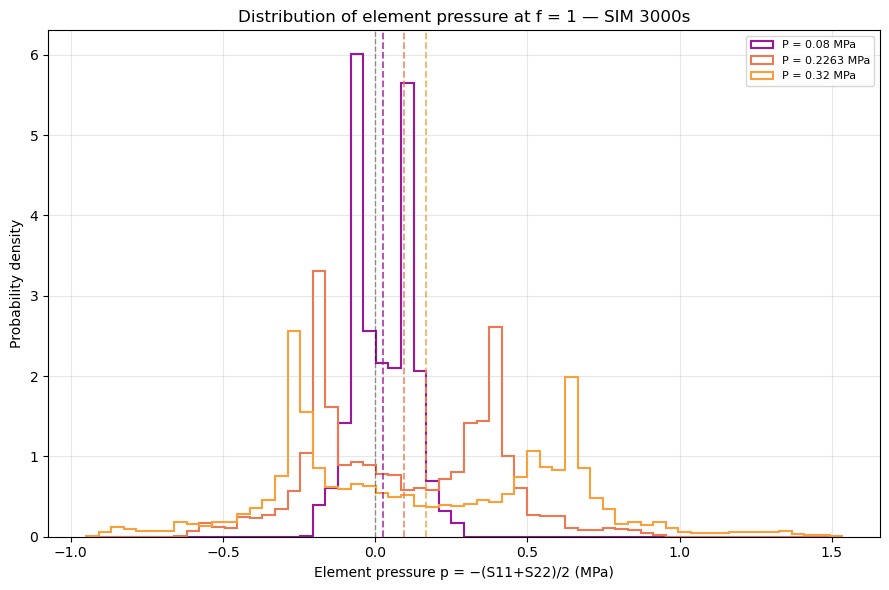

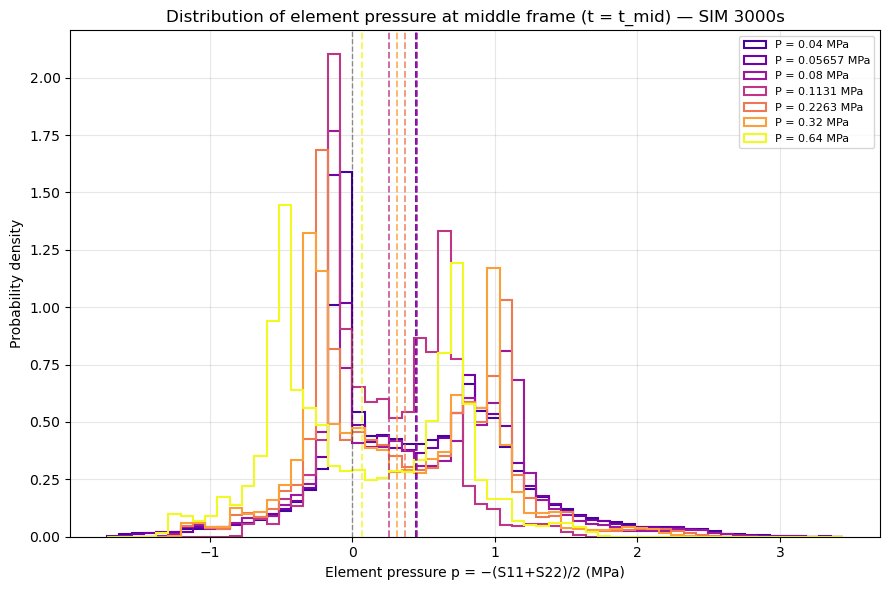

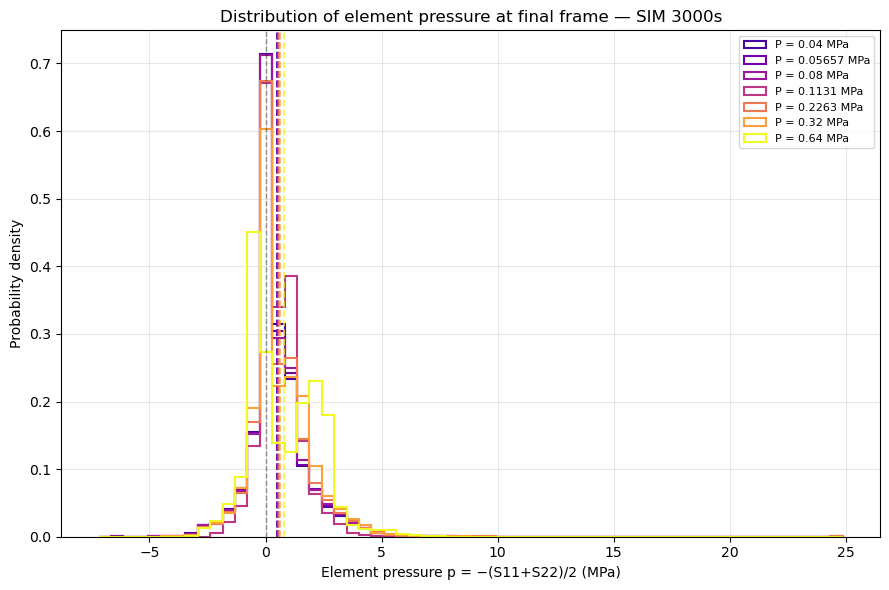

In [49]:
LANDMARK_LABELS = {
    't0':      't = 0',
    'epsstar': 'ε = ε*  (Localization A)',
    'f1':      'f = 1',
    'mid':     'middle frame (t = t_mid)',
    'final':   'final frame',
}

cmap = plt.get_cmap('plasma', len(SIMS))

for name, label in LANDMARK_LABELS.items():
    vals_by_sim = {}
    for sim in SIMS:
        if sim not in P_CACHE:
            continue
        snapshots = P_CACHE[sim].get('snapshots', {})
        values = snapshots.get(name)
        if values is not None:
            vals_by_sim[sim] = values
    if not vals_by_sim:
        continue

    all_vals = np.concatenate(list(vals_by_sim.values()))
    bins = np.linspace(all_vals.min(), all_vals.max(), 61)

    fig, ax = plt.subplots(figsize=(9, 6))
    for idx, sim in enumerate(SIMS):
        if sim not in vals_by_sim:
            continue
        ax.hist(vals_by_sim[sim], bins=bins, histtype='step', density=True, linewidth=1.5,
                color=cmap(idx), label=f'P = {PRESSURES[sim]:.4g} MPa')
        ax.axvline(vals_by_sim[sim].mean(), color=cmap(idx), linestyle='--',
                   linewidth=1.3, alpha=0.8, zorder=4)

    ax.axvline(0.0, color='k', linestyle='--', linewidth=1, alpha=0.4)
    ax.set_xlabel('Element pressure p = −(S11+S22)/2 (MPa)')
    ax.set_ylabel('Probability density')
    ax.set_title(f'Distribution of element pressure at {label} — {FAMILY_LABEL}')
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()


## Plot 15 — Mean skeleton pressure vs internal gas pressure

Tests the hypothesis that the compaction limit (`Localization A`, the minimum of
`shear_mean`) fires at a **fixed mean skeleton pressure**, rather than at a fixed strain.
On the 1010s family this held (`p*` constant to CV 1.6% while `eps*` varied by 92%) —
this cell re-runs the same test on the 3000s sweep; the numbers below will reflect
whatever the 3000s data actually shows, not the 1010s result.

**Mean skeleton pressure `p`** is the mean stress *inside the solid wall material*,
positive in compression — distinct from the gas pressure `P` and from the macroscopic
stress. It is read from `p_cache_3000s.pkl` (built by the *p cache* cell above), which holds the
**element average of `-(S11+S22)/2`** per frame, extracted once from the `DATA_PICK_{sim}_B.pkl`
files (~1.2 GB each). This is the direct FE measurement and is what the plot uses.

*Why not the kinematic shortcut.* `p` can also be inferred from the mean element area via
plane-stress elasticity, `p = -(A/A_undef - 1)·E/(2(1-nu))`, with no `_B.pkl` load. On the
1010s family that route matched the direct one to 0.3% at `t = 0` but underestimated by
~7% at the limit (linearises at finite areal strain, error grows with pressure) — do not
use the kinematic route for `p*` here either.

**Left panel** is the requested plot: `p` at `t = 0` (the gas-induced wall pre-tension) and
`p` at the limit (`p*`), both against gas pressure `P`. **Right panel** shows the full `p`
trajectories with the limit marked — if the hypothesis holds exactly, every marker sits
on one horizontal line.


loaded p_cache_3000s.pkl: sims [3001, 3002, 3003, 3004, 3006, 3007, 3009]


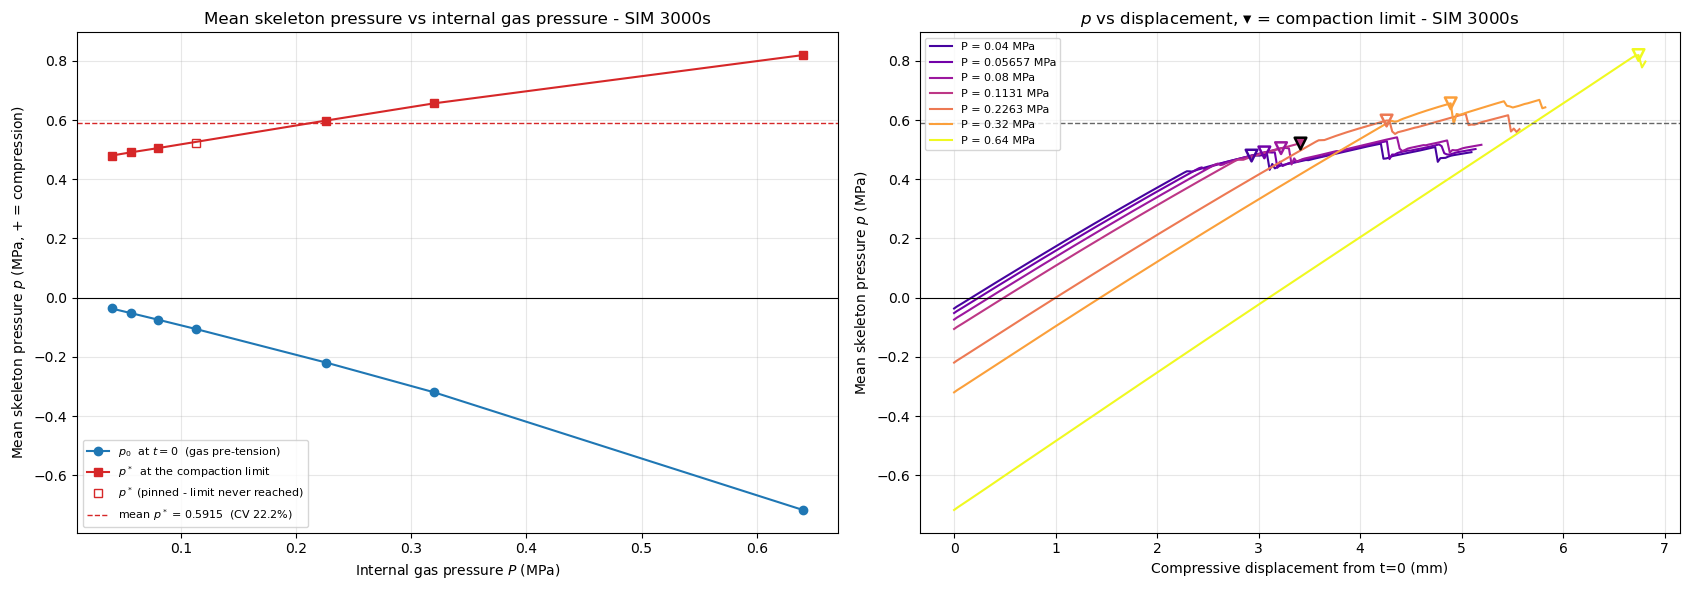

  sim       P     P/E    eps*       p0   p0/P       p*     p*/E
 3001   0.040  0.0020  0.1437  -0.0366  -0.92   0.4798  0.02399
 3002   0.057  0.0028  0.1487  -0.0520  -0.92   0.4906  0.02453
 3003   0.080  0.0040  0.1550  -0.0741  -0.93   0.5049  0.02525
 3004   0.113  0.0057  0.2500  -0.1059  -0.94   0.5209  0.02605  (pinned)
 3006   0.226  0.0113  0.1913  -0.2194  -0.97   0.5982  0.02991
 3007   0.320  0.0160  0.2100  -0.3198  -1.00   0.6563  0.03282
 3009   0.640  0.0320  0.2475  -0.7171  -1.12   0.8193  0.04096

p*/E : mean 0.02958  CV 22.2%  drift +70.7% across the sweep
eps*  : mean 0.1827  CV 22.5%  spread 1.72x

=> p*/E CV = 22.2%  vs eps* CV = 22.5%  (on the 1010s family p* was ~constant, CV 1.6%, while eps* varied by 92% -- compare these two CVs to see whether the same holds here).


In [50]:
# Plot 15 - mean skeleton pressure vs internal gas pressure.
# p comes from the element-average cache (direct FE stress); see the markdown above.
E_MOD = 20.0
P_CACHE = 'p_cache_3000s.pkl'

with open(P_CACHE, 'rb') as fh:
    PSKEL = pickle.load(fh)
print(f'loaded {P_CACHE}: sims {sorted(PSKEL)}')

rows = []
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(17, 6))
cmap = plt.get_cmap('plasma', len(SIMS))

for idx, sim in enumerate(SIMS):
    a2   = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_A2.pkl'))
    tp2l = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_TP2_L.pkl'))
    if a2 is None or tp2l is None or sim not in PRESSURES or sim not in PSKEL:
        del a2, tp2l
        continue
    displ = -np.array(a2['U2']['PERN-9999997'])
    shear = np.array(tp2l['shear_mean'])
    p     = np.asarray(PSKEL[sim]['mean_p'], dtype=float)
    del a2, tp2l

    displ_zero = displ - displ[0]
    i_star     = first_local_min(shear)
    pinned     = (i_star == len(shear) - 1)   # minimum on the last frame = never reached

    rows.append(dict(sim=sim, P=PRESSURES[sim], p0=p[0], p_star=p[i_star],
                     eps_star=5.0 * (i_star / (len(shear) - 1)) / 20.0, pinned=pinned))

    ax2.plot(displ_zero, p, color=cmap(idx), label=f'P = {PRESSURES[sim]:.4g} MPa')
    ax2.scatter(displ_zero[i_star], p[i_star], marker='v', s=70,
                facecolor='none' if not pinned else cmap(idx),
                edgecolor=cmap(idx) if not pinned else 'k', linewidths=1.8, zorder=5)

rows.sort(key=lambda r: r['P'])
Pg     = np.array([r['P']      for r in rows])
p0     = np.array([r['p0']     for r in rows])
pstar  = np.array([r['p_star'] for r in rows])
pinned = np.array([r['pinned'] for r in rows], dtype=bool)
ok     = ~pinned

if not rows:
    plt.close(fig)
    missing = [s for s in SIMS
               if not os.path.exists(os.path.join(RESULTS_DIR, f'DATA_PICK_{s}_TP2_L.pkl'))]
    print('Plot 15 skipped: no sim contributed a row.')
    print(f'  sims in {P_CACHE}: {sorted(PSKEL)}')
    print(f'  sims missing DATA_PICK_<sim>_TP2_L.pkl: {missing}')
    print('  -> run the TP1/TP2 reduction stages for the completed simulations, then re-run this cell.')
else:
    ax.plot(Pg, p0, 'o-', color='tab:blue', label=r'$p_0$  at $t=0$  (gas pre-tension)')
    ax.plot(Pg[ok], pstar[ok], 's-', color='tab:red', label=r'$p^*$  at the compaction limit')
    if pinned.any():
        ax.plot(Pg[pinned], pstar[pinned], 's', mfc='none', color='tab:red',
                label=r'$p^*$ (pinned - limit never reached)')
    ax.axhline(0, color='k', lw=0.8)
    ax.axhline(pstar[ok].mean(), color='tab:red', ls='--', lw=1,
               label=fr'mean $p^*$ = {pstar[ok].mean():.4f}  (CV {100*pstar[ok].std(ddof=1)/pstar[ok].mean():.1f}%)')
    ax.set_xlabel('Internal gas pressure $P$ (MPa)')
    ax.set_ylabel('Mean skeleton pressure $p$ (MPa, + = compression)')
    ax.set_title('Mean skeleton pressure vs internal gas pressure - SIM 3000s')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    ax2.axhline(0, color='k', lw=0.8)
    ax2.axhline(pstar[ok].mean(), color='0.4', ls='--', lw=1)
    ax2.set_xlabel('Compressive displacement from t=0 (mm)')
    ax2.set_ylabel('Mean skeleton pressure $p$ (MPa)')
    ax2.set_title(r'$p$ vs displacement, $\blacktriangledown$ = compaction limit - SIM 3000s')
    ax2.legend(fontsize=8, loc='upper left')
    ax2.grid(True, alpha=0.3)

    fig.tight_layout()
    plt.show()

    print(f"{'sim':>5}{'P':>8}{'P/E':>8}{'eps*':>8}{'p0':>9}{'p0/P':>7}{'p*':>9}{'p*/E':>9}")
    for r in rows:
        tag = '  (pinned)' if r['pinned'] else ''
        r0 = r['p0'] / r['P'] if r['P'] else float('nan')
        print(f"{r['sim']:>5}{r['P']:>8.3f}{r['P']/E_MOD:>8.4f}{r['eps_star']:>8.4f}"
              f"{r['p0']:>9.4f}{r0:>7.2f}{r['p_star']:>9.4f}{r['p_star']/E_MOD:>9.5f}{tag}")

    es = np.array([r['eps_star'] for r in rows])[ok]
    print(f"\np*/E : mean {(pstar[ok]/E_MOD).mean():.5f}  CV {100*pstar[ok].std(ddof=1)/pstar[ok].mean():.1f}%"
          f"  drift {100*(pstar[ok][-1]/pstar[ok][0]-1):+.1f}% across the sweep")
    print(f"eps*  : mean {es.mean():.4f}  CV {100*es.std(ddof=1)/es.mean():.1f}%  spread {es.max()/es.min():.2f}x")
    print(f"\n=> p*/E CV = {100*pstar[ok].std(ddof=1)/pstar[ok].mean():.1f}%  "
          f"vs eps* CV = {100*es.std(ddof=1)/es.mean():.1f}%  "
          "(on the 1010s family p* was ~constant, CV 1.6%, while eps* varied by 92% -- "
          "compare these two CVs to see whether the same holds here).")



## Percolation caches (built once)

The three plots below need per-frame network statistics that are **not** in the light result
files. Each is built once and cached next to this notebook, following the same pattern as the
shear/J caches above. Re-run this cell after deleting a cache to rebuild it.

| cache | contents | cost |
|---|---|---|
| `bar_fraction_cache_3000s.pkl` | tension-bar fraction, `f`, bar-force mean/median/skew per frame | ~20 min (reads the nine 254 MB `_I2_3002.pkl`) |
| `cluster_diagnostics_3000s.pkl` | per frame, both graphs: largest cluster, 2nd-largest, susceptibility, cluster count | ~25 min (same source) |
| `random_percolation_null_3000s.pkl` | random-bond null model on the same overlay: `f`, `S1`, `S2`, `chi` vs `q` | ~7 min |

Each is skipped if the file already exists **and** carries the keys the plots need — a stale
cache missing a key is rebuilt rather than causing a `KeyError` further down.


In [51]:
# Build the percolation caches if missing or incomplete.
import itertools
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components, shortest_path

MESH_GRIDHEX = os.path.join('..', 'C001_Mesh_files', 'A1000_I3002.gridhex.json')
N_OVERLAY    = 10575          # all overlay nodes; used as the denominator everywhere

REQUIRED = {
    'bar_fraction_cache_3000s.pkl':      ('frac_tension', 'f', 'i_star', 'frame_f1'),
    'cluster_diagnostics_3000s.pkl':     ('lcc_t', 'lcc2_t', 'chi_t', 'lcc_c', 'lcc2_c',
                                          'chi_c', 'frac_tension', 'i_star'),
    'random_percolation_null_3000s.pkl': ('q', 'f_mean', 'lcc', 'lcc2', 'chi', 'n_sources'),
}

def cache_ok(path, per_sim=True):
    """True if the cache exists and carries every key the plots need."""
    if not os.path.exists(path):
        return False
    try:
        with open(path, 'rb') as fh:
            d = pickle.load(fh)
        probe = next(iter(d.values())) if per_sim else d
        return all(k in probe for k in REQUIRED[os.path.basename(path)])
    except Exception:
        return False

# ---- 1 & 2: per-frame graph statistics from the I2 pickles --------------------
need_bf = not cache_ok('bar_fraction_cache_3000s.pkl')
need_cl = not cache_ok('cluster_diagnostics_3000s.pkl')
if need_bf or need_cl:
    print(f'building I2-derived caches (bar_fraction={need_bf}, clusters={need_cl}) - this is slow')
    import networkx as nx  # noqa: F401  (I2 pickles hold networkx graphs)
    from scipy import stats
    BF_new, CL_new = {}, {}
    for sim in SIMS:
        path = resolve_path(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_I2_3002.pkl'))
        if path is None:
            continue
        with open(path, 'rb') as fh:
            d2 = pickle.load(fh)
        T, C = d2['tension'], d2['compression']
        keys = sorted(T.keys(), key=lambda k: int(k))
        n = len(keys)
        bf = {k: np.zeros(n) for k in ('frac_tension', 'mean_axial_force',
                                       'median_axial_force', 'skew_axial_force')}
        cl = {k: np.zeros(n) for k in ('lcc_t', 'lcc2_t', 'chi_t', 'nc_t',
                                       'lcc_c', 'lcc2_c', 'chi_c', 'nc_c')}

        def diag(edges):
            if len(edges) == 0:
                return 0.0, 0.0, 1.0, N_OVERLAY
            A = csr_matrix((np.ones(len(edges)), (edges[:, 0], edges[:, 1])),
                           shape=(N_OVERLAY, N_OVERLAY))
            A = A + A.T
            nc, lab = connected_components(A, directed=False)
            s = np.sort(np.bincount(lab))[::-1]
            rest = s[1:]
            chi = (rest ** 2).sum() / rest.sum() if rest.sum() > 0 else 0.0
            return s[0] / N_OVERLAY, (s[1] / N_OVERLAY if len(s) > 1 else 0.0), chi, nc

        for j, ti in enumerate(keys):
            at = np.fromiter((e[2]['axial_force'] for e in T[ti].edges(data=True)), float)
            ac = np.fromiter((e[2]['axial_force'] for e in C[ti].edges(data=True)), float)
            a = np.concatenate([at, ac])
            bf['frac_tension'][j]      = len(at) / len(a)
            bf['mean_axial_force'][j]  = a.mean()
            bf['median_axial_force'][j] = np.median(a)
            bf['skew_axial_force'][j]  = stats.skew(a)
            et = np.fromiter((x for e in T[ti].edges() for x in e), int).reshape(-1, 2)
            ec = np.fromiter((x for e in C[ti].edges() for x in e), int).reshape(-1, 2)
            (cl['lcc_t'][j], cl['lcc2_t'][j], cl['chi_t'][j], cl['nc_t'][j]) = diag(et)
            (cl['lcc_c'][j], cl['lcc2_c'][j], cl['chi_c'][j], cl['nc_c'][j]) = diag(ec)
        del d2, T, C

        i3   = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_I3_BFS_3002.pkl'))
        tp2l = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_TP2_L.pkl'))
        eft = np.array(i3['global_ef_t'], float); efc = np.array(i3['global_ef_c'], float)
        f   = np.where(efc != 0, eft / efc, np.nan)
        i_star = first_local_min(np.array(tp2l['shear_mean']))
        kf = np.nan
        for k in range(1, len(f)):
            if np.isfinite(f[k - 1]) and np.isfinite(f[k]) and f[k - 1] > 1 >= f[k]:
                kf = k - 1 + (f[k - 1] - 1) / (f[k - 1] - f[k]); break

        BF_new[sim] = dict(t=np.array(tp2l['t'], float), f=f, i_star=i_star,
                           frame_f1=float(kf), n_overlay_nodes=N_OVERLAY, **bf)
        CL_new[sim] = dict(frac_tension=bf['frac_tension'], i_star=i_star,
                           frame_f1=float(kf), N=N_OVERLAY, **cl)
        print(f'  {sim} done')
    if need_bf:
        with open('bar_fraction_cache_3000s.pkl', 'wb') as fh:
            pickle.dump(BF_new, fh)
    if need_cl:
        with open('cluster_diagnostics_3000s.pkl', 'wb') as fh:
            pickle.dump(CL_new, fh)
else:
    print('I2-derived caches present and complete')

# ---- 3: random-bond null model on the same overlay ---------------------------
if not cache_ok('random_percolation_null_3000s.pkl', per_sim=False):
    print('building random_percolation_null_3000s.pkl')
    with open(MESH_GRIDHEX) as fh:
        _g = json.load(fh)
    Eb = np.array([[b['start'], b['end']] for b in _g['bars']])
    Nn = len(_g['nodes'])
    rng = np.random.default_rng(23)
    K   = 400
    src = rng.choice(Nn, K, replace=False)

    def _A(edges):
        A = csr_matrix((np.ones(len(edges)), (edges[:, 0], edges[:, 1])), shape=(Nn, Nn))
        return A + A.T

    def _eff(A):
        D = shortest_path(A, method='D', unweighted=True, indices=src)
        with np.errstate(divide='ignore'):
            inv = np.where(np.isfinite(D) & (D > 0), 1.0 / D, 0.0)
        return inv.sum() / (K * (Nn - 1))

    def _clus(A):
        nc, lab = connected_components(A, directed=False)
        s = np.sort(np.bincount(lab))[::-1]; rest = s[1:]
        return s[0] / Nn, (s[1] / Nn if len(s) > 1 else 0.0), (rest ** 2).sum() / rest.sum()

    qs = np.arange(0.30, 0.921, 0.02); TR = 3
    F = np.zeros((len(qs), TR)); L = np.zeros((len(qs), TR))
    L2 = np.zeros((len(qs), TR)); X = np.zeros((len(qs), TR))
    for i, q in enumerate(qs):
        for t in range(TR):
            m = rng.random(len(Eb)) < q
            At, Ac = _A(Eb[m]), _A(Eb[~m])
            F[i, t] = _eff(At) / _eff(Ac)
            L[i, t], L2[i, t], X[i, t] = _clus(At)
    with open('random_percolation_null_3000s.pkl', 'wb') as fh:
        pickle.dump(dict(q=qs, f_mean=F.mean(1), f_std=F.std(1),
                         lcc=L.mean(1), lcc_sd=L.std(1),
                         lcc2=L2.mean(1), lcc2_sd=L2.std(1),
                         chi=X.mean(1), chi_sd=X.std(1),
                         n_trials=TR, n_sources=K, seed=23, N=Nn,
                         note='random bond-assignment null model on the A1000_I3002 overlay'), fh)
    print('  done')
else:
    print('random_percolation_null_3000s.pkl present and complete')


building I2-derived caches (bar_fraction=True, clusters=True) - this is slow


ValueError: row index exceeds matrix dimensions

## Plot 16 — Is `f` a percolation quantity? The collapse, and why there may be no kink at `q_c`

`f = E_glob(tension) / E_glob(compression)` is a ratio of network connectivities, so the
natural question is whether it behaves as a **percolation** observable — governed by the
*fraction* `q` of bars carrying the tension label, independently of everything else.

**Test:** plot `f` against `q` for every sim. If `f` is a function of `q` alone, all curves
lie on top of each other. On the 1010s family they did — at fixed `q` the spread across the
pressure sweep was 0.7-12% (mostly under 5%) while `f` itself spanned two orders of
magnitude, so `f` was a near-universal function of the bond fraction for that lattice. This
cell re-runs the same collapse test on the 3000s sweep below; whether it collapses as
cleanly here is an open question until the cell runs on real data.

### How `q_c` was obtained on the 1010s family, and why it need not produce a kink

`q_c ~ 0.60-0.65` was measured by **random bond percolation on this overlay's real
topology** (same mesh/overlay as the 3000s family, `A1000_I3002.gridhex.json`): keep each
bar independently with probability `q`, and track the **largest connected component**
(LCC) as the order parameter. On the 1010s family the steepest rise of LCC/N fell between
0.60 and 0.65, while `f(q)` itself was smooth and monotone there, with no kink. The reasoning:
global efficiency averages `1/d` over every pair, so it is dominated by short-range
connections that exist on both sides of a percolation threshold and grows continuously
through a transition that LCC registers abruptly — a property of the metric, not of the
physics. The middle/right panels below re-run the null model and collapse-quality check
directly on this notebook's SIMS.


In [52]:
def plot_percolation_collapse():
    required = ('random_percolation_null_3000s.pkl',)
    missing = [path for path in required if not os.path.exists(path)]
    if missing:
        print(f'Plot 16 skipped: missing {missing}')
        return
    # Plot 16 - the f vs bond-fraction collapse, with the random null model for reference.
    # If the per-sim cache is empty or stale, rebuild what we need from the
    # available reduced files instead of skipping the plot.
    Q_C = (0.60, 0.65)
    CACHE_BF   = 'bar_fraction_cache_3000s.pkl'
    CACHE_NULL = 'random_percolation_null_3000s.pkl'
    BF = {}
    if os.path.exists(CACHE_BF):
        try:
            with open(CACHE_BF, 'rb') as fh:
                BF = pickle.load(fh)
        except Exception:
            BF = {}
    if not BF or any(sim not in BF for sim in SIMS):
        print('Plot 16: rebuilding bar-fraction cache from available reduced files')
        from scipy import stats
        from scipy.sparse import csr_matrix
        from scipy.sparse.csgraph import connected_components
        N_OVERLAY = 10575
        def diag(edges):
            if len(edges) == 0:
                return 0.0, 0.0, 1.0, N_OVERLAY
            A = csr_matrix((np.ones(len(edges)), (edges[:, 0], edges[:, 1])), shape=(N_OVERLAY, N_OVERLAY))
            A = A + A.T
            nc, lab = connected_components(A, directed=False)
            s = np.sort(np.bincount(lab))[::-1]
            rest = s[1:]
            chi = (rest ** 2).sum() / rest.sum() if rest.sum() > 0 else 0.0
            return s[0] / N_OVERLAY, (s[1] / N_OVERLAY if len(s) > 1 else 0.0), chi, nc
        BF_new = {}
        for sim in SIMS:
            i2_path = resolve_path(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_I2_3002.pkl'))
            i3 = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_I3_BFS_3002.pkl'))
            tp2l = load_pkl(os.path.join(RESULTS_DIR, f'DATA_PICK_{sim}_TP2_L.pkl'))
            if i2_path is None or i3 is None or tp2l is None:
                continue
            with open(i2_path, 'rb') as fh:
                d2 = pickle.load(fh)
            T, C = d2['tension'], d2['compression']
            keys = sorted(T.keys(), key=lambda k: int(k))
            n = len(keys)
            bf = {k: np.zeros(n) for k in ('frac_tension', 'mean_axial_force', 'median_axial_force', 'skew_axial_force')}
            lcc_t = np.zeros(n)
            lcc2_t = np.zeros(n)
            chi_t = np.zeros(n)
            nc_t = np.zeros(n)
            lcc_c = np.zeros(n)
            lcc2_c = np.zeros(n)
            chi_c = np.zeros(n)
            nc_c = np.zeros(n)
            lcc_points = []
            for j, ti in enumerate(keys):
                at = np.fromiter((e[2]['axial_force'] for e in T[ti].edges(data=True)), float)
                ac = np.fromiter((e[2]['axial_force'] for e in C[ti].edges(data=True)), float)
                a = np.concatenate([at, ac])
                bf['frac_tension'][j] = len(at) / len(a) if len(a) else np.nan
                bf['mean_axial_force'][j] = a.mean() if len(a) else np.nan
                bf['median_axial_force'][j] = np.median(a) if len(a) else np.nan
                bf['skew_axial_force'][j] = 0.0 if len(a) < 3 else float(stats.skew(a))
                et = np.fromiter((x for e in T[ti].edges() for x in e), int).reshape(-1, 2) if len(at) else np.empty((0, 2), dtype=int)
                ec = np.fromiter((x for e in C[ti].edges() for x in e), int).reshape(-1, 2) if len(ac) else np.empty((0, 2), dtype=int)
                lcc_t[j], lcc2_t[j], chi_t[j], nc_t[j] = diag(et)
                lcc_c[j], lcc2_c[j], chi_c[j], nc_c[j] = diag(ec)
                lcc_points.append({'q': float(bf['frac_tension'][j]), 'lcc_tension': float(lcc_t[j])})
            eft = np.array(i3['global_ef_t'], float)
            efc = np.array(i3['global_ef_c'], float)
            f = np.where(efc != 0, eft / efc, np.nan)
            i_star = first_local_min(np.array(tp2l['shear_mean']))
            kf = np.nan
            for k in range(1, len(f)):
                if np.isfinite(f[k - 1]) and np.isfinite(f[k]) and f[k - 1] > 1 >= f[k]:
                    kf = k - 1 + (f[k - 1] - 1) / (f[k - 1] - f[k])
                    break
            BF_new[sim] = dict(t=np.array(tp2l['t'], float), f=f, i_star=i_star,
                               frame_f1=float(kf), n_overlay_nodes=N_OVERLAY,
                               lcc_points=lcc_points, **bf)
        BF = BF_new
        with open(CACHE_BF, 'wb') as fh:
            pickle.dump(BF, fh)
    with open(CACHE_NULL, 'rb') as fh:
        NULL = pickle.load(fh)
    print(f'loaded {CACHE_BF} ({len(BF)} sims) and {CACHE_NULL} '
          f'({NULL["n_trials"]} trials/point, {NULL["n_sources"]} BFS sources)')
    
    fig, (ax, axm, ax2) = plt.subplots(1, 3, figsize=(20, 5.8))
    cmap = plt.get_cmap('plasma', len(SIMS))
    
    # ---- panel 1: f vs q, real sims + random null model --------------------------
    for idx, sim in enumerate(SIMS):
        if sim not in BF or sim not in PRESSURES:
            continue
        q, f, i_star = BF[sim]['frac_tension'], BF[sim]['f'], BF[sim]['i_star']
        m = np.isfinite(f) & (f > 0)
        ax.plot(q[m], f[m], color=cmap(idx), lw=1.4, label=f'P = {PRESSURES[sim]:.4g} MPa')
        if np.isfinite(f[i_star]) and f[i_star] > 0:
            ax.scatter(q[i_star], f[i_star], marker='v', s=80, facecolor='none',
                       edgecolor=cmap(idx), linewidths=1.8, zorder=6)
    ax.plot(NULL['q'], NULL['f_mean'], 'k--', lw=1.6, zorder=7)
    ax.axhline(1.0, color='k', lw=0.8, ls=':')
    ax.axvspan(*Q_C, color='0.75', alpha=0.35, zorder=0)
    ax.set_yscale('log')
    ax.set_xlabel('tension-bar fraction  $q$')
    ax.set_ylabel(r'$f = \eta_{tension}/\eta_{compression}$')
    ax.set_title('$f$ collapses onto one curve - and has no kink at $q_c$')
    h, l = ax.get_legend_handles_labels()
    h += [Line2D([], [], marker='v', ls='None', mfc='none', mec='k', ms=8),
          Line2D([], [], color='k', ls='--'), Line2D([], [], color='0.75', lw=8)]
    l += ['compaction limit', 'random null model', r'$q_c$ (random) 0.60-0.65']
    ax.legend(h, l, loc='upper left', fontsize=7.5)
    ax.grid(True, alpha=0.3, which='both')
    
    # ---- panel 2: LCC/N - where the transition IS visible ------------------------
    axm.errorbar(NULL['q'], NULL['lcc'], yerr=NULL['lcc_sd'], fmt='k--o', ms=4, lw=1.6,
                 capsize=3, label='random null model')
    for idx, sim in enumerate(SIMS):
        if sim not in BF:
            continue
        pts = BF[sim].get('lcc_points', [])
        if pts:
            axm.scatter([p['q'] for p in pts], [p['lcc_tension'] for p in pts],
                        color=cmap(idx), s=45, zorder=5,
                        label='real tension network' if idx == 1 else None)
    axm.axvspan(*Q_C, color='0.75', alpha=0.35, zorder=0)
    axm.set_xlabel('tension-bar fraction  $q$')
    axm.set_ylabel('largest connected component / N')
    axm.set_title('The transition IS sharp - in the largest cluster')
    axm.legend(fontsize=8, loc='upper left')
    axm.grid(True, alpha=0.3)
    
    # ---- panel 3: collapse quality ----------------------------------------------
    grid = np.array([0.42, 0.44, 0.46, 0.50, 0.55, 0.60, 0.65, 0.70, 0.80])
    vals = []
    for sim in SIMS:
        if sim not in BF:
            continue
        q, f = BF[sim]['frac_tension'], BF[sim]['f']
        m = np.isfinite(f) & (f > 0)
        if m.sum() < 10 or np.nanmax(q[m]) < grid.max():
            continue                       # SIM 3000 (P=0) has no usable f
        o = np.argsort(q[m])
        vals.append(np.interp(grid, q[m][o], f[m][o]))
    vals = np.array(vals)
    cv = 100 * vals.std(axis=0, ddof=1) / vals.mean(axis=0)
    ax2.plot(grid, cv, 'o-', color='tab:red')
    ax2.axvspan(*Q_C, color='0.75', alpha=0.35, zorder=0)
    ax2.set_xlabel('tension-bar fraction  $q$')
    ax2.set_ylabel('spread of $f$ across the sweep (CV, %)')
    ax2.set_title(f'Collapse quality ({vals.shape[0]} sims): worst CV = {cv.max():.1f} %')
    ax2.set_ylim(0, max(15, cv.max() * 1.2))
    ax2.grid(True, alpha=0.3)
    
    fig.tight_layout()
    plt.show()
    
    print(f"{'q':>7}" + "".join(f"{v:>9.2f}" for v in grid))
    print(f"{'CV %':>7}" + "".join(f"{v:>9.1f}" for v in cv))
    print(f"\nf spans {vals.min():.2f} .. {vals.max():.0f}, yet at fixed q it varies by at most "
          f"{cv.max():.1f}% across the sweep => f is a function of the bond fraction.")
    print("\nRandom null model - the transition is sharp in LCC, invisible in f:")
    print(f"{'q':>7}{'LCC/N':>9}{'f_rand':>10}")
    for qq, ll, ff in zip(NULL['q'], NULL['lcc'], NULL['f_mean']):
        print(f"{qq:>7.2f}{ll:>9.4f}{ff:>10.3f}")
    print("   LCC/N rises ~40x across q=0.44->0.72; f_rand rises smoothly with no kink at q_c.")

plot_percolation_collapse()


Plot 16: rebuilding bar-fraction cache from available reduced files


ValueError: row index exceeds matrix dimensions

## Plot 17 — Is there a sharp percolation transition in the real networks?

Plot 16 shows `f(q)` (on the 1010s family) rising smoothly with no kink at `q_c`. That is
a property of *global efficiency*, which averages `1/d` over all pairs and therefore grows
continuously through a transition. To see whether a transition exists at all, use the
standard finite-size locators instead:

| locator | behaviour at the threshold |
|---|---|
| largest cluster `S₁/N` | rises steeply (the order parameter) |
| **2nd-largest cluster `S₂/N`** | **peaks** — the giant cluster is still assembling from competing pieces |
| **susceptibility `chi = Σ' s² / Σ' s`** (over all clusters *except* the largest) | **peaks sharply** — the standard locator |

`chi` is the mean cluster size a randomly chosen non-giant node belongs to. Below the
threshold clusters are small; above it everything has been absorbed into the giant cluster;
right at it, clusters of every size coexist and `chi` diverges (peaks, in a finite system).

### What to look for

On the 1010s family this locator found an unmistakable transition in the real tension
network, sitting at a **lower** bond fraction than random deletion (the stress field is
spatially correlated and therefore percolates more easily than random bar removal), while
the compression network percolated close to the random threshold. Panel 4 below plots
where each network's `chi` peak sits, per sim, against gas pressure `P`, so the same
comparison can be read off directly for the 3000s sweep once it has run.

Data: `cluster_diagnostics_3000s.pkl` (per-frame connected components of both graphs, all
sims in `SIMS`) and `random_percolation_null_3000s.pkl` (random-bond null model on the same
overlay).


In [ ]:
def plot_percolation_diagnostics():
    required = ('cluster_diagnostics_3000s.pkl', 'random_percolation_null_3000s.pkl')
    missing = [path for path in required if not os.path.exists(path)]
    if missing:
        print(f'Plot 17 skipped: missing {missing}')
        return
    with open(required[0], 'rb') as fh:
        if not pickle.load(fh):
            print('Plot 17 skipped: cluster-diagnostics cache has no simulations yet.')
            return
    # Plot 17 - percolation diagnostics: does the real network show a sharp transition?
    CACHE_CL   = 'cluster_diagnostics_3000s.pkl'
    CACHE_NULL = 'random_percolation_null_3000s.pkl'
    with open(CACHE_CL, 'rb') as fh:   CL = pickle.load(fh)
    with open(CACHE_NULL, 'rb') as fh: NULL = pickle.load(fh)
    print(f'loaded {CACHE_CL} ({len(CL)} sims) and {CACHE_NULL} ({NULL["n_trials"]} trials/point)')
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 11))
    (a1, a2), (a3, a4) = axes
    cmap = plt.get_cmap('plasma', len(SIMS))
    
    def null_band(ax, key, sd):
        ax.plot(NULL['q'], NULL[key], 'k--', lw=1.8, zorder=8, label='random null model')
        ax.fill_between(NULL['q'], NULL[key] - NULL[sd], NULL[key] + NULL[sd],
                        color='k', alpha=0.12, zorder=0)
    
    for idx, sim in enumerate(SIMS):
        if sim not in CL:
            continue
        d = CL[sim]; q = d['frac_tension']
        lab = f'P = {PRESSURES[sim]:.4g} MPa'
        a1.plot(q, d['lcc_t'],  color=cmap(idx), lw=1.3, label=lab)
        a2.plot(q, d['lcc2_t'], color=cmap(idx), lw=1.3, label=lab)
        a3.plot(q, d['chi_t'],  color=cmap(idx), lw=1.3, label=lab)
        # mark the transition (susceptibility peak)
        ip = int(np.argmax(d['chi_t']))
        a3.scatter(q[ip], d['chi_t'][ip], color=cmap(idx), s=45, zorder=6)
        a2.scatter(q[int(np.argmax(d['lcc2_t']))], d['lcc2_t'].max(), color=cmap(idx), s=45, zorder=6)
    
    null_band(a1, 'lcc', 'lcc_sd'); null_band(a2, 'lcc2', 'lcc2_sd'); null_band(a3, 'chi', 'chi_sd')
    
    a1.set_ylabel('largest cluster  $S_1/N$'); a1.set_title('Order parameter: giant cluster')
    a2.set_ylabel('2nd-largest cluster  $S_2/N$'); a2.set_title('$S_2$ PEAKS at the transition')
    a3.set_ylabel(r'susceptibility  $\chi$'); a3.set_title(r'$\chi$ PEAKS at the transition')
    for ax in (a1, a2, a3):
        ax.set_xlabel('tension-bar fraction  $q$')
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0.30, 0.95)
    a1.legend(fontsize=7, loc='upper left')
    a3.legend(fontsize=7, loc='upper left')
    
    # ---- panel 4: where the transition sits, vs gas pressure ---------------------
    Pv, qt, qc = [], [], []
    for sim in SIMS:
        if sim not in CL or sim not in PRESSURES or sim == 3000:
            continue                      # SIM 3000 (P=0) has no tension network to speak of
        d = CL[sim]; q = d['frac_tension']
        Pv.append(PRESSURES[sim])
        qt.append(q[int(np.argmax(d['chi_t']))])
        qc.append(1.0 - q[int(np.argmax(d['chi_c']))])
    a4.plot(Pv, qt, 'o-', color='tab:red',  label=r'tension network, $q$ at $\chi$ peak')
    a4.plot(Pv, qc, 's-', color='tab:blue', label=r'compression network, $1-q$ at $\chi$ peak')
    a4.axhspan(NULL['q'][np.argmax(NULL['lcc2'])], NULL['q'][np.argmax(NULL['chi'])],
               color='0.7', alpha=0.4, zorder=0, label='random null threshold 0.62-0.68')
    a4.set_xlabel('internal gas pressure $P$ (MPa)')
    a4.set_ylabel('bond fraction at the transition')
    a4.set_title('Where each network percolates')
    a4.legend(fontsize=8); a4.grid(True, alpha=0.3)
    
    fig.tight_layout()
    plt.show()
    
    print(f"\n{'sim':>5}{'q @ chi peak (T)':>18}{'peak chi_t':>12}{'1-q @ chi peak (C)':>20}{'frame':>7}{'f=1 frame':>11}{'ti*':>6}")
    for sim in SIMS:
        if sim not in CL:
            continue
        d = CL[sim]; q = d['frac_tension']
        it = int(np.argmax(d['chi_t'])); ic = int(np.argmax(d['chi_c']))
        print(f"{sim:>5}{q[it]:>18.4f}{d['chi_t'][it]:>12.1f}{1-q[ic]:>20.4f}"
              f"{it:>7}{d['frame_f1']:>11.1f}{d['i_star']:>6}")
    print(f"\nrandom null model: S2 peaks at q = {NULL['q'][np.argmax(NULL['lcc2'])]:.2f}, "
          f"chi peaks at q = {NULL['q'][np.argmax(NULL['chi'])]:.2f}, peak chi = {NULL['chi'].max():.0f}")
    print('\n=> compare the tension/compression transition locations above against the '
          'random null-model thresholds (S2/chi peaks) to see whether the real network '
          'percolates below, at, or above the random threshold on this sweep.')

plot_percolation_diagnostics()
